# 💸 BUDU — SpendBehavior Analyzer
## Data Science Pipeline · Dataset Dummy Indonesia · IDR Edition
**Coding Camp 2026 – DBS Foundation | Tim CC26-PSU268**

---

### Alur Eksekusi Notebook (jalankan berurutan)

| Bagian | Cell | Konten | Checklist |
|---|---|---|---|
| **A. Setup** | 0 | Library & konfigurasi global | - |
| **B. Generate Data** | 1–3 | Generate 1.000 user + ~50.000 transaksi Indonesia | Gathering Data |
| **C. Assessing** | 4 | Evaluasi kualitas & struktur data | Assessing Data |
| **D. Cleaning** | 5 | Wrangling end-to-end | Cleaning Data |
| **E. Business Questions** | 6 | 6 pertanyaan SMART + IDR | Pertanyaan Bisnis |
| **F. EDA** | 7–12 | Q1–Q6 dengan visualisasi explanatory | EDA + Visualisasi |
| **G. A/B Testing** | 13 | Mann-Whitney U (weekend vs weekday) | Side Quest |
| **H. Feature Engineering** | 14–15 | Fitur level transaksi & user | Side Quest |
| **I. Clustering** | 16–17 | Spending Persona (Elbow + Silhouette) | EDA |
| **J. Persiapan Model TF** | 18 | Encode + Normalisasi + Split 70/15/15 | Data siap model |
| **K. Saran AI** | 19 | Arsitektur TF + tools lengkap | Handoff AI Engineer |
| **L. Export** | 20 | CSV + .npy + metadata JSON | Export |
| **M. Data Dictionary** | 21 | Dokumentasi lengkap semua fitur | Data Dictionary |

### Checklist DS — Coverage
| Kategori | Item | Status |
|---|---|---|
| **Main Quest** | Data Wrangling end-to-end | ✅ |
| **Main Quest** | Business Questions SMART | ✅ |
| **Main Quest** | EDA + Explanatory Analysis | ✅ |
| **Main Quest** | Visualisasi Data | ✅ |
| **Main Quest** | Data Dictionary | ✅ |
| **Main Quest** | Data siap diproses model | ✅ |
| **Side Quest** | Feature Engineering informatif | ✅ |
| **Side Quest** | A/B Testing Python | ✅ |

---
## ⚙️ Cell 0 — Setup & Import Library

In [1]:
# !pip install faker --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os, json
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   MinMaxScaler)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6','#EC4899','#F97316']
PRIMARY, ACCENT, WARN = '#2563EB', '#10B981', '#EF4444'

# ── Threshold global ────────────────────────────────────────
NIGHT_START          = 20
ANOMALY_STD_FACTOR   = 1.5
SMALL_TXN_MULTIPLIER = 0.5
FREQ_MONTH_THRESH    = 10
IMPULSE_THRESHOLD    = 0.55
RANDOM_SEED          = 42
np.random.seed(RANDOM_SEED)

print('Setup selesai.')
print(f'  Threshold  : Anomali >{ANOMALY_STD_FACTOR}SD | Malam >={NIGHT_START}:00 | Impulse >={IMPULSE_THRESHOLD}')

Setup selesai.
  Threshold  : Anomali >1.5SD | Malam >=20:00 | Impulse >=0.55


---
## 🇮🇩 BAGIAN B — Generate Dataset Dummy Indonesia

### Cell 1 — Definisi Segmen & Referensi Indonesia

In [2]:
# ============================================================
# CELL 1 — Profil Segmen Sosio-Ekonomi Indonesia
# ============================================================

SEGMENTS = {
    'E': {
        'label'          : 'Kelas E (Miskin)',
        'pct_pop'        : 0.15,
        'income_range'   : (800_000, 1_500_000),
        'spending_ratio' : (0.85, 0.98),
        'txn_per_month'  : (8, 20),
        'txn_amount_dist': 'low',
        'payment_methods': {'Tunai': 0.55, 'GoPay': 0.25, 'OVO': 0.12, 'DANA': 0.08},
        'categories'     : {
            'Sembako & Kebutuhan Pokok': 0.40,
            'Transportasi'             : 0.20,
            'Pulsa & Data'             : 0.15,
            'Makanan & Minuman'        : 0.15,
            'Kesehatan'                : 0.05,
            'Pendidikan'               : 0.05,
        },
        'city_tier'      : {'Desa': 0.45, 'Kota Kecil': 0.40, 'Kota Besar': 0.15},
        'age_range'      : (18, 55),
        'weekend_boost'  : 1.05,
        'night_prob'     : 0.08,
        'impulse_base'   : 0.15,
        'jobs'           : ['Buruh Tani', 'Pedagang Kaki Lima', 'Nelayan',
                            'Buruh Pabrik', 'Asisten Rumah Tangga', 'Ojek Konvensional'],
    },
    'D': {
        'label'          : 'Kelas D (Menengah Bawah)',
        'pct_pop'        : 0.25,
        'income_range'   : (1_500_000, 3_000_000),
        'spending_ratio' : (0.75, 0.92),
        'txn_per_month'  : (15, 35),
        'txn_amount_dist': 'low_mid',
        'payment_methods': {'Tunai': 0.30, 'GoPay': 0.30, 'OVO': 0.20,
                            'DANA': 0.12, 'Transfer Bank': 0.08},
        'categories'     : {
            'Sembako & Kebutuhan Pokok': 0.28,
            'Makanan & Minuman'        : 0.22,
            'Transportasi'             : 0.18,
            'Pulsa & Data'             : 0.12,
            'Fashion & Pakaian'        : 0.08,
            'Kesehatan'                : 0.06,
            'Pendidikan'               : 0.04,
            'Hiburan'                  : 0.02,
        },
        'city_tier'      : {'Desa': 0.20, 'Kota Kecil': 0.45, 'Kota Besar': 0.35},
        'age_range'      : (18, 50),
        'weekend_boost'  : 1.15,
        'night_prob'     : 0.15,
        'impulse_base'   : 0.25,
        'jobs'           : ['Driver Ojek Online', 'Karyawan Toko', 'Guru Honorer',
                            'Admin Kantor', 'Teknisi', 'Pedagang Warung', 'SPG/SPB'],
    },
    'C': {
        'label'          : 'Kelas C (Menengah)',
        'pct_pop'        : 0.35,
        'income_range'   : (3_000_000, 7_000_000),
        'spending_ratio' : (0.60, 0.82),
        'txn_per_month'  : (25, 60),
        'txn_amount_dist': 'mid',
        'payment_methods': {'GoPay': 0.25, 'OVO': 0.20, 'Kartu Debit': 0.20,
                            'Transfer Bank': 0.15, 'DANA': 0.12, 'Tunai': 0.08},
        'categories'     : {
            'Makanan & Minuman'        : 0.25,
            'Belanja Online'           : 0.18,
            'Sembako & Kebutuhan Pokok': 0.15,
            'Fashion & Pakaian'        : 0.10,
            'Transportasi'             : 0.10,
            'Hiburan'                  : 0.08,
            'Kesehatan & Kecantikan'   : 0.06,
            'Pulsa & Data'             : 0.05,
            'Pendidikan'               : 0.03,
        },
        'city_tier'      : {'Kota Kecil': 0.30, 'Kota Besar': 0.55, 'Metropolitan': 0.15},
        'age_range'      : (18, 45),
        'weekend_boost'  : 1.30,
        'night_prob'     : 0.25,
        'impulse_base'   : 0.40,
        'jobs'           : ['Pegawai Swasta', 'PNS Golongan II', 'Guru Tetap',
                            'Staf Administrasi', 'Wirausaha Kecil', 'Perawat', 'Sales'],
    },
    'B': {
        'label'          : 'Kelas B (Menengah Atas)',
        'pct_pop'        : 0.18,
        'income_range'   : (7_000_000, 20_000_000),
        'spending_ratio' : (0.45, 0.70),
        'txn_per_month'  : (40, 90),
        'txn_amount_dist': 'mid_high',
        'payment_methods': {'Kartu Kredit': 0.30, 'Kartu Debit': 0.25,
                            'GoPay': 0.18, 'Transfer Bank': 0.15,
                            'OVO': 0.08, 'ShopeePay': 0.04},
        'categories'     : {
            'Makanan & Minuman'  : 0.22, 'Belanja Online': 0.18,
            'Fashion & Pakaian'  : 0.12, 'Hiburan'       : 0.10,
            'Transportasi'       : 0.09, 'Kecantikan & Perawatan': 0.08,
            'Elektronik'         : 0.07, 'Restoran & Kafe': 0.07,
            'Olahraga & Gym'     : 0.04, 'Travel & Hotel': 0.03,
        },
        'city_tier'      : {'Kota Besar': 0.45, 'Metropolitan': 0.55},
        'age_range'      : (22, 50),
        'weekend_boost'  : 1.50,
        'night_prob'     : 0.35,
        'impulse_base'   : 0.55,
        'jobs'           : ['Manajer', 'Pengacara', 'Dokter', 'Engineer Senior',
                            'Dosen', 'Wirausaha Menengah', 'Analis Keuangan', 'Arsitek'],
    },
    'A': {
        'label'          : 'Kelas A (Kaya)',
        'pct_pop'        : 0.07,
        'income_range'   : (20_000_000, 150_000_000),
        'spending_ratio' : (0.25, 0.55),
        'txn_per_month'  : (50, 150),
        'txn_amount_dist': 'high',
        'payment_methods': {'Kartu Kredit': 0.45, 'Transfer Bank': 0.30,
                            'Kartu Debit': 0.15, 'GoPay': 0.10},
        'categories'     : {
            'Restoran & Kafe'    : 0.18, 'Travel & Hotel'    : 0.15,
            'Fashion & Pakaian'  : 0.13, 'Elektronik'        : 0.10,
            'Kecantikan & Perawatan': 0.08, 'Hiburan'        : 0.08,
            'Belanja Online'     : 0.08, 'Olahraga & Gym'    : 0.07,
            'Investasi & Asuransi': 0.07, 'Properti & Renovasi': 0.06,
        },
        'city_tier'      : {'Metropolitan': 0.75, 'Kota Besar': 0.25},
        'age_range'      : (25, 60),
        'weekend_boost'  : 1.70,
        'night_prob'     : 0.45,
        'impulse_base'   : 0.65,
        'jobs'           : ['CEO/Direktur', 'Pengusaha', 'Konsultan Senior',
                            'Dokter Spesialis', 'Investor', 'Artis/Influencer',
                            'Notaris', 'Partner Law Firm'],
    },
}

SUB_CATEGORIES = {
    'Sembako & Kebutuhan Pokok': ['Indomaret','Alfamart','Pasar Tradisional','Warung Sembako','Giant','Hypermart','Lotte Mart','Superindo'],
    'Makanan & Minuman'        : ['GoFood/GrabFood','Warteg','Warung Padang','Mie Ayam & Bakso','Geprek/Ayam Goreng','Indomie Rebus','Kopi Jahe/Wedang','Jus Buah'],
    'Restoran & Kafe'          : ['Kopi Kenangan','Fore Coffee','Starbucks',"McDonald's",'KFC','Pizza Hut','Sushi Tei','Holycow Steak','Rooftop Restaurant'],
    'Transportasi'             : ['Gojek','Grab','Angkot','Bus Kota','KRL Commuter','MRT Jakarta','BBM Pertamina','Parkir','Toll'],
    'Belanja Online'           : ['Shopee','Tokopedia','Lazada','Blibli','Tiktok Shop','Zalora','JD.ID','Bukalapak'],
    'Fashion & Pakaian'        : ['H&M','Zara','Uniqlo','Cotton On','Erigo','Pasar Baju','Brand Lokal IG','Batik Keris','Matahari Dept Store'],
    'Hiburan'                  : ['CGV Cinemas','XXI Cinema','Netflix/Spotify','Karaoke','Game Online','Taman Wisata','Konser Musik','Bioskop Drive-in'],
    'Kesehatan'                : ['Apotek Kimia Farma','Guardian','Klinik Pratama','Puskesmas','RS Umum','Dokter Praktek','Laboratorium'],
    'Kesehatan & Kecantikan'   : ['Apotek K-24','Guardian','Watsons','The Body Shop','Klinik Kecantikan','Sociolla','Base (Skincare Lokal)'],
    'Kecantikan & Perawatan'   : ['Erha Clinic','ZAP Clinic','Sociolla Premium','Salon Premium','Spa & Wellness','Dermatologist Private'],
    'Pulsa & Data'             : ['Telkomsel','Indosat Ooredoo','XL Axiata','Tri (3)','Smartfren','IndiHome','Myrepublic'],
    'Pendidikan'               : ['Bimbel Primagama','Ruangguru','Zenius','Coursera','SPP Sekolah','Alat Tulis','Buku Teks','Udemy'],
    'Elektronik'               : ['iBox Apple','Samsung Store','iQOO','Erafone','JD.ID Electronics','Tokopedia Electronics','Charger/Aksesori'],
    'Olahraga & Gym'           : ['Fitness First','Celebrity Fitness',"Gold's Gym",'Lapangan Futsal','Kolam Renang','Badminton','Nike/Adidas Store'],
    'Travel & Hotel'           : ['Traveloka','Tiket.com','Airbnb','Airy Rooms','Hotel Bintang 3','Resort Bali','Penginapan Murah'],
    'Investasi & Asuransi'     : ['Bibit','Bareksa','Pluang','BPJS Kesehatan','Asuransi Prudential','AIA Financial','Reksa Dana Mandiri'],
    'Properti & Renovasi'      : ['ACE Hardware','Depo Bangunan','IKEA','Vivere','Kontraktor Renovasi','Cat Dulux','Mebel Custom'],
}

CITIES = {
    'Desa'        : [('Desa Sukamaju',5_000),('Desa Makmur',3_200),('Desa Sejahtera',4_100),
                     ('Desa Cikaret',2_800),('Desa Rawa Indah',6_500),('Desa Panyingkiran',3_700)],
    'Kota Kecil'  : [('Tasikmalaya',700_000),('Cirebon',320_000),('Purwokerto',290_000),
                     ('Magelang',130_000),('Tegal',285_000),('Pekalongan',310_000),
                     ('Kediri',320_000),('Blitar',150_000),('Jombang',190_000)],
    'Kota Besar'  : [('Bandung',2_500_000),('Surabaya',3_100_000),('Medan',2_400_000),
                     ('Semarang',1_800_000),('Makassar',1_500_000),('Palembang',1_700_000),
                     ('Denpasar',900_000),('Yogyakarta',420_000)],
    'Metropolitan': [('Jakarta',10_500_000),('Bekasi',2_700_000),('Depok',2_200_000),
                     ('Tangerang',2_100_000),('Bogor',1_100_000),('Tangerang Selatan',1_700_000)],
}

CITY_COORDS = {
    'Jakarta':(-6.2088,106.8456),'Bekasi':(-6.2349,106.9896),'Depok':(-6.4025,106.7942),
    'Tangerang':(-6.1702,106.6402),'Bogor':(-6.5971,106.8060),'Tangerang Selatan':(-6.2867,106.7104),
    'Bandung':(-6.9175,107.6191),'Surabaya':(-7.2575,112.7521),'Medan':(3.5952,98.6722),
    'Semarang':(-6.9932,110.4203),'Makassar':(-5.1477,119.4327),'Palembang':(-2.9761,104.7754),
    'Denpasar':(-8.6705,115.2126),'Yogyakarta':(-7.7956,110.3695),'Tasikmalaya':(-7.3506,108.2183),
    'Cirebon':(-6.7320,108.5523),'Purwokerto':(-7.4216,109.2425),'Magelang':(-7.4797,110.2177),
    'Tegal':(-6.8694,109.1402),'Pekalongan':(-6.8886,109.6753),'Kediri':(-7.8165,112.0112),
    'Blitar':(-8.0983,112.1686),'Jombang':(-7.5478,112.2289),
}

print('[OK] Segmen & referensi Indonesia dimuat')
print(f'  Segmen   : {list(SEGMENTS.keys())}')
print(f'  Kategori : {len(SUB_CATEGORIES)} kategori utama')
print(f'  Kota     : {sum(len(v) for v in CITIES.values())} kota/desa')

[OK] Segmen & referensi Indonesia dimuat
  Segmen   : ['E', 'D', 'C', 'B', 'A']
  Kategori : 17 kategori utama
  Kota     : 29 kota/desa


### Cell 2 — Generate 1.000 Profil User Indonesia

In [3]:
# ============================================================
# CELL 2 — Generate 1.000 User Indonesia
# ============================================================

N_USERS = 1_000

NAMA_DEPAN_L = ['Budi','Andi','Deni','Fajar','Hendra','Rizki','Agus','Doni','Eko',
    'Fery','Galih','Hadi','Irwan','Joko','Kevin','Lutfi','Maman','Nanda',
    'Oki','Prio','Rudi','Samsul','Tono','Udin','Vino','Wahyu','Yanto','Zulfi',
    'Ahmad','Bagas','Candra','Dimas','Erwin','Firmansyah','Gilang','Hafizh',
    'Ivan','Januar','Kukuh','Lukman','Mulyadi','Nanang','Oscar','Putra']
NAMA_DEPAN_P = ['Siti','Ani','Dewi','Rina','Wulan','Maya','Nisa','Putri','Rini','Sari',
    'Tari','Ulfa','Vina','Wati','Yuni','Zara','Ayu','Bella','Clara','Dinda',
    'Ella','Fitri','Gita','Hana','Indri','Julia','Kiki','Lina','Mira','Nadia',
    'Okta','Prita','Rahma','Sinta','Tiara','Uci','Vevi','Widya','Yanti',
    'Afifah','Bunga','Cantika','Dhea','Elisa','Farida','Hasna','Intan']
NAMA_BELAKANG = ['Santoso','Wijaya','Susanto','Purwanto','Setiawan','Rahayu','Kurniawan',
    'Hidayat','Purnomo','Saputra','Wahyudi','Nugroho','Pratama','Sanjaya',
    'Wibowo','Hartono','Gunawan','Kusuma','Sutrisno','Harahap','Nasution',
    'Siregar','Lubis','Rajasa','Mahendra','Yulianto','Firmansyah','Prasetyo',
    'Budiman','Iskandar']

def pick_city(tier):
    opts = CITIES[tier]
    return opts[np.random.randint(0, len(opts))]

def get_coords(city_name, jitter=0.5):
    base = CITY_COORDS.get(city_name, (-6.2, 106.8))
    return (round(base[0]+np.random.uniform(-jitter,jitter),4),
            round(base[1]+np.random.uniform(-jitter,jitter),4))

np.random.seed(RANDOM_SEED)
seg_keys  = list(SEGMENTS.keys())
seg_probs = [SEGMENTS[s]['pct_pop'] for s in seg_keys]
users = []

for uid in range(1, N_USERS+1):
    seg_key = np.random.choice(seg_keys, p=seg_probs)
    seg     = SEGMENTS[seg_key]
    gender  = np.random.choice(['L','P'], p=[0.52,0.48])
    nama_d  = np.random.choice(NAMA_DEPAN_L if gender=='L' else NAMA_DEPAN_P)
    nama_b  = np.random.choice(NAMA_BELAKANG)
    age     = int(np.random.uniform(*seg['age_range']))
    income  = int(np.random.uniform(*seg['income_range']))
    city_tier = np.random.choice(list(seg['city_tier'].keys()),
                                  p=list(seg['city_tier'].values()))
    city_name, city_pop = pick_city(city_tier)
    lat, long_ = get_coords(city_name)
    spend_ratio   = np.random.uniform(*seg['spending_ratio'])
    monthly_spend = round(income * spend_ratio)
    users.append({
        'user_id'          : f'BUDU{uid:05d}',
        'nama'             : f'{nama_d} {nama_b}',
        'gender'           : gender,
        'usia'             : age,
        'segmen'           : seg_key,
        'segmen_label'     : seg['label'],
        'pekerjaan'        : np.random.choice(seg['jobs']),
        'kota'             : city_name,
        'tier_kota'        : city_tier,
        'populasi_kota'    : city_pop,
        'lat'              : lat,
        'long'             : long_,
        'pendapatan_bulan' : income,
        'pengeluaran_bulan': monthly_spend,
        'tabungan_bulan'   : income - monthly_spend,
        'spending_ratio'   : round(spend_ratio, 3),
        'impulse_base'     : seg['impulse_base'],
    })

df_users = pd.DataFrame(users)
assert df_users.isnull().sum().sum() == 0, 'Ada null di df_users!'

print('[OK] User profile berhasil dibuat')
print(f'  Total user     : {len(df_users):,}')
print(f'  Tidak ada null : OK')
print()
print('Distribusi segmen:')
for seg, grp in df_users.groupby('segmen_label'):
    print(f'  {seg:35s}: {len(grp):3d} user ({len(grp)/len(df_users)*100:.1f}%)')
print()
print('Statistik pendapatan per segmen (IDR):')
stat = df_users.groupby('segmen_label')['pendapatan_bulan'].agg(['min','mean','max'])
print(stat.apply(lambda c: c.apply(lambda v: f'Rp {v:,.0f}')).to_string())

[OK] User profile berhasil dibuat
  Total user     : 1,000
  Tidak ada null : OK

Distribusi segmen:
  Kelas A (Kaya)                     :  64 user (6.4%)
  Kelas B (Menengah Atas)            : 168 user (16.8%)
  Kelas C (Menengah)                 : 386 user (38.6%)
  Kelas D (Menengah Bawah)           : 230 user (23.0%)
  Kelas E (Miskin)                   : 152 user (15.2%)

Statistik pendapatan per segmen (IDR):
                                    min           mean             max
segmen_label                                                          
Kelas A (Kaya)            Rp 20,922,549  Rp 78,873,497  Rp 143,899,340
Kelas B (Menengah Atas)    Rp 7,003,087  Rp 13,313,958   Rp 19,950,918
Kelas C (Menengah)         Rp 3,018,017   Rp 4,938,515    Rp 6,996,197
Kelas D (Menengah Bawah)   Rp 1,501,533   Rp 2,283,317    Rp 2,999,561
Kelas E (Miskin)             Rp 800,650   Rp 1,161,405    Rp 1,496,215


### Cell 3 — Generate ~50.000 Transaksi Realistis

In [4]:
# ============================================================
# CELL 3 — Generate ~50.000 Transaksi Indonesia
# ============================================================

N_TRANSACTIONS = 50_000
DATE_START      = '2023-01-01'
DATE_END        = '2025-01-01'

TXN_AMOUNT_PARAMS = {
    'low'     : {'mean': 25_000,    'std': 12_000,  'min': 2_000,    'max': 100_000},
    'low_mid' : {'mean': 60_000,    'std': 35_000,  'min': 5_000,    'max': 250_000},
    'mid'     : {'mean': 150_000,   'std': 100_000, 'min': 10_000,   'max': 700_000},
    'mid_high': {'mean': 400_000,   'std': 300_000, 'min': 25_000,   'max': 3_000_000},
    'high'    : {'mean': 1_200_000, 'std': 900_000, 'min': 50_000,   'max': 25_000_000},
}

SEASON_BOOST = {
    1:1.05, 2:0.90, 3:0.95, 4:1.00, 5:1.25,
    6:1.35, 7:1.10, 8:0.95, 9:0.90, 10:0.95, 11:1.05, 12:1.30,
}

def sample_amount(dist_type, category):
    p   = TXN_AMOUNT_PARAMS[dist_type]
    raw = np.random.lognormal(np.log(p['mean']), 0.7, 1)
    raw = np.clip(raw, p['min'], p['max'])
    if category in ['Travel & Hotel','Elektronik','Properti & Renovasi',
                    'Investasi & Asuransi','Restoran & Kafe']:
        raw *= np.random.uniform(1.5, 3.5)
    if category in ['Pulsa & Data','Sembako & Kebutuhan Pokok','Transportasi']:
        raw *= np.random.uniform(0.3, 0.7)
    return float(np.clip(raw, p['min'], p['max'])[0])

# Jam probability (biased ke jam sibuk)
hour_probs = np.array([
    0.5,0.3,0.2,0.2,0.2,0.3,
    0.8,2.5,2.5,1.5,1.2,1.5,
    2.8,2.0,1.5,1.5,1.8,2.5,
    3.0,3.2,2.8,2.0,1.2,0.8,
])
hour_probs /= hour_probs.sum()

np.random.seed(RANDOM_SEED)

# Hitung jatah transaksi per user
user_txn_counts = {}
for _, u in df_users.iterrows():
    seg = SEGMENTS[u['segmen']]
    tmin, tmax = seg['txn_per_month']
    user_txn_counts[u['user_id']] = int(np.random.uniform(tmin, tmax) * 24)
scale = N_TRANSACTIONS / sum(user_txn_counts.values())
user_txn_counts = {uid: max(10, int(v*scale)) for uid, v in user_txn_counts.items()}

transactions = []
txn_id = 1

print('Generating transactions...')
for _, u in df_users.iterrows():
    uid     = u['user_id']
    seg_key = u['segmen']
    seg     = SEGMENTS[seg_key]
    n_txn   = user_txn_counts[uid]

    cat_keys  = list(seg['categories'].keys())
    cat_p     = np.array(list(seg['categories'].values())); cat_p /= cat_p.sum()
    pay_keys  = list(seg['payment_methods'].keys())
    pay_p     = np.array(list(seg['payment_methods'].values())); pay_p /= pay_p.sum()
    dist_type = seg['txn_amount_dist']
    fraud_prob = {'E':0.003,'D':0.005,'C':0.008,'B':0.012,'A':0.018}.get(seg_key, 0.005)
    merch_lat  = round(u['lat']  + np.random.uniform(-0.3, 0.3), 4)
    merch_long = round(u['long'] + np.random.uniform(-0.3, 0.3), 4)

    for _ in range(n_txn):
        day  = pd.Timestamp(DATE_START) + pd.Timedelta(days=np.random.randint(0, 730))
        hour = np.random.choice(range(24), p=hour_probs)
        txn_date = day.replace(hour=hour,
                               minute=np.random.randint(0,60),
                               second=np.random.randint(0,60))
        category = np.random.choice(cat_keys, p=cat_p)
        sub_cat  = np.random.choice(SUB_CATEGORIES.get(category, [category]))
        payment  = np.random.choice(pay_keys, p=pay_p)
        seasonal = SEASON_BOOST.get(txn_date.month, 1.0)
        amount   = round(sample_amount(dist_type, category) * seasonal / 100) * 100
        amount   = max(1_000, int(amount))
        is_fraud = int(np.random.random() < fraud_prob)
        is_night = int(txn_date.hour >= NIGHT_START)
        is_wknd  = int(txn_date.dayofweek >= 5)
        m_lat    = round(merch_lat  + np.random.uniform(-0.05, 0.05), 4)
        m_long   = round(merch_long + np.random.uniform(-0.05, 0.05), 4)
        dist     = round(((m_lat-u['lat'])**2 + (m_long-u['long'])**2)**0.5, 4)

        transactions.append({
            'txn_id'             : f'TXN{txn_id:07d}',
            'user_id'            : uid,
            'date'               : txn_date.strftime('%Y-%m-%d %H:%M:%S'),
            'amount'             : amount,
            'category'           : category,
            'sub_category'       : sub_cat,
            'payment_method'     : payment,
            'gender'             : u['gender'],
            'usia'               : int(u['usia']),
            'segmen'             : seg_key,
            'segmen_label'       : u['segmen_label'],
            'pekerjaan'          : u['pekerjaan'],
            'kota'               : u['kota'],
            'tier_kota'          : u['tier_kota'],
            'populasi_kota'      : int(u['populasi_kota']),
            'pendapatan_bulan'   : int(u['pendapatan_bulan']),
            'spending_ratio'     : float(u['spending_ratio']),
            'user_lat'           : u['lat'],
            'user_long'          : u['long'],
            'merch_lat'          : m_lat,
            'merch_long'         : m_long,
            'dist_user_merchant' : dist,
            'is_fraud'           : is_fraud,
            'is_night'           : is_night,
            'is_weekend'         : is_wknd,
            'month'              : txn_date.month,
            'day_of_week'        : txn_date.dayofweek,
            'hour'               : txn_date.hour,
            'quarter'            : txn_date.quarter,
            'is_month_start'     : int(txn_date.day <= 5),
            'is_month_end'       : int(txn_date.day >= 25),
        })
        txn_id += 1

df_txn = pd.DataFrame(transactions)
df_txn['date'] = pd.to_datetime(df_txn['date'])
assert df_txn.isnull().sum().sum() == 0, 'Ada null!'

print(f'[OK] Transaksi berhasil dibuat!')
print(f'  Total transaksi : {len(df_txn):,}')
print(f'  Total user      : {df_txn["user_id"].nunique():,}')
print(f'  Tidak ada null  : OK')
print()
print('Distribusi per segmen:')
for seg, grp in df_txn.groupby('segmen_label'):
    print(f'  {seg:35s}: {len(grp):6,} txn ({len(grp)/len(df_txn)*100:.1f}%) | avg Rp {grp["amount"].mean():,.0f}')

Generating transactions...
[OK] Transaksi berhasil dibuat!
  Total transaksi : 49,503
  Total user      : 1,000
  Tidak ada null  : OK

Distribusi per segmen:
  Kelas A (Kaya)                     :  7,911 txn (16.0%) | avg Rp 2,965,769
  Kelas B (Menengah Atas)            : 13,184 txn (26.6%) | avg Rp 639,766
  Kelas C (Menengah)                 : 19,208 txn (38.8%) | avg Rp 170,880
  Kelas D (Menengah Bawah)           :  6,725 txn (13.6%) | avg Rp 56,150
  Kelas E (Miskin)                   :  2,475 txn (5.0%) | avg Rp 19,946


---
## 🔍 BAGIAN C — Assessing Data

### Cell 4 — Struktur, Kualitas & Statistik Deskriptif

In [5]:
# ============================================================
# CELL 4 — Assessing Data
# ============================================================
df = df_txn.copy()

print('='*60)
print(f'Shape        : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'Periode      : {df["date"].min().date()} s/d {df["date"].max().date()}')
print(f'Sumber       : Dataset Dummy Indonesia (IDR)')
print('='*60)
display(df.head(3))
df.info()

# Missing values
print('\nMissing values:')
miss = df.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else '  Tidak ada missing value.')

# Duplikat
dup = df.duplicated().sum()
print(f'\nDuplikat : {dup:,} ({dup/len(df)*100:.2f}%)')

# Kategorik
print('\nDistribusi kolom kategorik:')
cat_cols = [c for c in df.select_dtypes('object').columns if df[c].nunique() <= 50]
for col in cat_cols[:6]:
    top = df[col].value_counts().head(3).to_dict()
    print(f'  {col:30s}: {df[col].nunique():3d} unik | top: {top}')

# Fraud check
print(f'\nLabel is_fraud:')
fd = df['is_fraud'].value_counts()
for k,v in fd.items():
    print(f'  {"Fraud" if k==1 else "Normal":6s}: {v:,} ({v/len(df)*100:.2f}%)')

# Statistik deskriptif numerik
print('\nStatistik deskriptif numerik:')
num_cols = df.select_dtypes(include='number').columns.tolist()
display(df[num_cols].describe().T.round(2))


Shape        : 49,503 baris x 31 kolom
Periode      : 2023-01-01 s/d 2024-12-30
Sumber       : Dataset Dummy Indonesia (IDR)


,txn_id,user_id,date,amount,category,sub_category,payment_method,gender,usia,segmen,...,dist_user_merchant,is_fraud,is_night,is_weekend,month,day_of_week,hour,quarter,is_month_start,is_month_end
0,TXN0000001,BUDU00001,2023-08-04 19:30:20,20600,Pulsa & Data,Smartfren,OVO,P,37,D,...,0.16,0,0,0,8,4,19,3,1,0
1,TXN0000002,BUDU00001,2023-02-16 05:15:06,84100,Hiburan,XXI Cinema,GoPay,P,37,D,...,0.24,0,0,0,2,3,5,1,0,0
2,TXN0000003,BUDU00001,2023-05-17 08:07:49,76500,Makanan & Minuman,Geprek/Ayam Goreng,GoPay,P,37,D,...,0.16,0,0,0,5,2,8,2,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49503 entries, 0 to 49502
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   txn_id              49503 non-null  object        
 1   user_id             49503 non-null  object        
 2   date                49503 non-null  datetime64[ns]
 3   amount              49503 non-null  int64         
 4   category            49503 non-null  object        
 5   sub_category        49503 non-null  object        
 6   payment_method      49503 non-null  object        
 7   gender              49503 non-null  object        
 8   usia                49503 non-null  int64         
 9   segmen              49503 non-null  object        
 10  segmen_label        49503 non-null  object        
 11  pekerjaan           49503 non-null  object        
 12  kota                49503 non-null  object        
 13  tier_kota           49503 non-null  object    

,count,mean,std,min,25%,50%,75%,max
amount,"49,503.00","719,271.88","1,602,681.05","1,800.00","74,100.00","199,300.00","614,600.00","32,500,000.00"
usia,"49,503.00",34.71,9.33,18.00,27.00,34.00,42.00,58.00
populasi_kota,"49,503.00","1,880,447.56","2,163,545.98","2,800.00","420,000.00","1,700,000.00","2,200,000.00","10,500,000.00"
pendapatan_bulan,"49,503.00","18,138,045.17","29,988,684.93","800,650.00","3,630,644.00","6,107,441.00","14,886,034.50","143,899,340.00"
spending_ratio,"49,503.00",0.65,0.16,0.25,0.54,0.67,0.77,0.98
user_lat,"49,503.00",-6.01,2.54,-9.17,-7.28,-6.55,-5.99,4.05
user_long,"49,503.00",108.67,4.22,98.19,106.68,107.27,110.47,119.93
merch_lat,"49,503.00",-6.01,2.54,-9.24,-7.26,-6.55,-5.97,4.28
merch_long,"49,503.00",108.67,4.21,97.88,106.66,107.41,110.48,120.11
dist_user_merchant,"49,503.00",0.23,0.09,0.00,0.17,0.24,0.30,0.47


---
## 🧹 BAGIAN D — Cleaning Data

### Cell 5 — Wrangling & Standardisasi

In [6]:
# ============================================================
# CELL 5 — Cleaning & Standardisasi
# ============================================================
report = {}

# 5.1 Fitur waktu dasar
df['month']          = df['date'].dt.month
df['day_of_week']    = df['date'].dt.dayofweek
df['hour']           = df['date'].dt.hour
df['day_name']       = df['date'].dt.day_name().str[:3]
df['week']           = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']     = df['day_of_week'].isin([5,6]).astype(int)
df['is_night']       = df['hour'].between(NIGHT_START, 23).astype(int)
df['is_month_start'] = (df['date'].dt.day <= 5).astype(int)
df['is_month_end']   = (df['date'].dt.day >= 25).astype(int)

# 5.2 Normalize teks
for col in ['category','sub_category','payment_method']:
    df[col] = df[col].astype(str).str.strip().str.title()

# 5.3 Hapus duplikat
before = len(df)
df.drop_duplicates(inplace=True)
report['removed_dup'] = before - len(df)

# 5.4 Amount minimal Rp 1.000
before = len(df)
df = df[df['amount'] >= 1_000]
report['removed_zero'] = before - len(df)

df.reset_index(drop=True, inplace=True)

# 5.5 Validasi akhir
null_total = df.isnull().sum().sum()
print('Setelah cleaning:')
print(f'  Shape          : {df.shape[0]:,} x {df.shape[1]}')
print(f'  Missing        : {null_total}')
print(f'  Duplikat hapus : {report["removed_dup"]:,}')
print(f'  Amount range   : Rp {int(df["amount"].min()):,} – Rp {int(df["amount"].max()):,}')
print(f'  Median amount  : Rp {int(df["amount"].median()):,}')
display(df.head(3))

Setelah cleaning:
  Shape          : 49,503 x 33
  Missing        : 0
  Duplikat hapus : 0
  Amount range   : Rp 1,800 – Rp 32,500,000
  Median amount  : Rp 199,300


,txn_id,user_id,date,amount,category,sub_category,payment_method,gender,usia,segmen,...,is_night,is_weekend,month,day_of_week,hour,quarter,is_month_start,is_month_end,day_name,week
0,TXN0000001,BUDU00001,2023-08-04 19:30:20,20600,Pulsa & Data,Smartfren,Ovo,P,37,D,...,0,0,8,4,19,3,1,0,Fri,31
1,TXN0000002,BUDU00001,2023-02-16 05:15:06,84100,Hiburan,Xxi Cinema,Gopay,P,37,D,...,0,0,2,3,5,1,0,0,Thu,7
2,TXN0000003,BUDU00001,2023-05-17 08:07:49,76500,Makanan & Minuman,Geprek/Ayam Goreng,Gopay,P,37,D,...,0,0,5,2,8,2,0,0,Wed,20


---
## ❓ BAGIAN E — Business Questions SMART

### Cell 6 — 6 Business Questions

> **Konteks BUDU:** Data transaksi 2 tahun (2023-2024) · 1.000 user · 5 segmen sosio-ekonomi Indonesia · Semua nilai dalam IDR

| No | Pertanyaan | Metrik | Target BUDU |
|---|---|---|---|
| Q1 | Kategori mana yang menyumbang ≥30% total pengeluaran? | % total IDR | Money Leak Warning |
| Q2 | Apakah rata-rata transaksi weekend ≥20% lebih tinggi dari weekday? | Selisih % | Smart Warning Jumat malam |
| Q3 | Bulan apa total pengeluaran melebihi mean + 1.5×SD? | Anomali bulan | Weekly Reflection alert |
| Q4 | Kategori mana yang bocor diam-diam (transaksi kecil, frekuensi tinggi)? | freq/bulan ≥10 | Silent Drain card |
| Q5 | Apakah metode pembayaran berkorelasi dengan nilai transaksi? (Spearman ρ ≥ 0.3) | ρ, p-value | Konteks warning per metode |
| Q6 | Berapa proporsi user dengan impulse_score ≥ 0.55? | % user | Segmen notifikasi prioritas |

---
## 📊 BAGIAN F — EDA & Explanatory Analysis

### Cell 7 — Q1: Distribusi Pengeluaran per Kategori

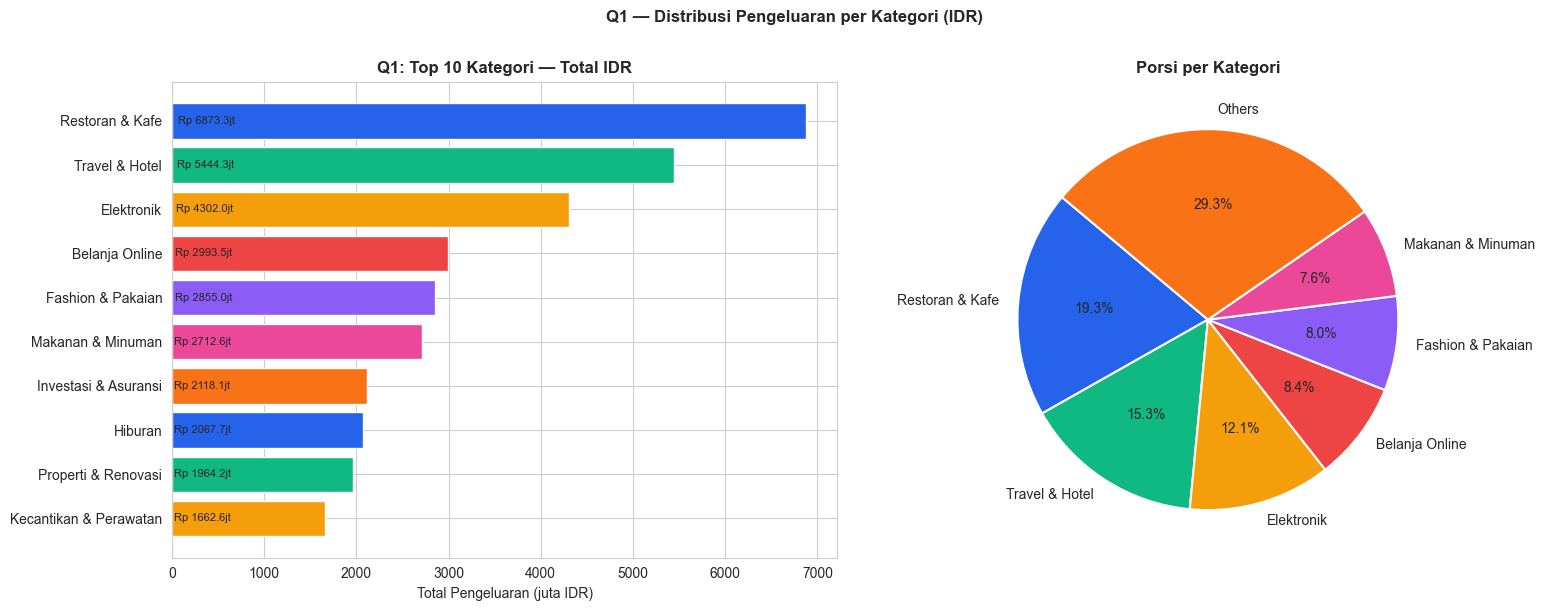


📌 Q1 ANSWER:
  Tidak ada kategori tunggal ≥ 30%.
  Terbesar: Restoran & Kafe (19.3% · Rp 6873.3jt)
  ➡️  BUDU: tampilkan top-3 sebagai "Money Leak Priority"


In [7]:
# ── Q1: Kategori vs Total Pengeluaran IDR ───────────────────
cat_grp = (df.groupby('category')['amount']
             .agg(total='sum', count='count', avg='mean')
             .sort_values('total', ascending=False))
cat_grp['persen'] = (cat_grp['total'] / cat_grp['total'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
top10 = cat_grp.head(10)
clrs  = [PALETTE[i % len(PALETTE)] for i in range(len(top10))]
axes[0].barh(top10.index[::-1], top10['total'][::-1]/1e6, color=clrs[::-1])
axes[0].set_xlabel('Total Pengeluaran (juta IDR)')
axes[0].set_title('Q1: Top 10 Kategori — Total IDR', fontweight='bold')
for i, v in enumerate(top10['total'][::-1]/1e6):
    axes[0].text(v*0.01, i, f'Rp {v:.1f}jt', va='center', fontsize=8)
top6  = cat_grp.head(6)
other = cat_grp['total'].iloc[6:].sum()
pie_v = list(top6['total'])   + ([other] if other>0 else [])
pie_l = list(top6.index)      + (['Others'] if other>0 else [])
axes[1].pie(pie_v, labels=pie_l, autopct='%1.1f%%',
            colors=PALETTE[:len(pie_v)], startangle=140,
            wedgeprops=dict(edgecolor='white', lw=1.5))
axes[1].set_title('Porsi per Kategori', fontweight='bold')
plt.suptitle('Q1 — Distribusi Pengeluaran per Kategori (IDR)', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

cat_30 = cat_grp[cat_grp['persen'] >= 30]
print('\n📌 Q1 ANSWER:')
if cat_30.empty:
    top1 = cat_grp.head(1)
    print(f'  Tidak ada kategori tunggal ≥ 30%.')
    print(f'  Terbesar: {top1.index[0]} ({top1["persen"].values[0]:.1f}% · Rp {top1["total"].values[0]/1e6:.1f}jt)')
    print('  ➡️  BUDU: tampilkan top-3 sebagai "Money Leak Priority"')
else:
    for cat, row in cat_30.iterrows():
        print(f'  ⚠️  {cat}: {row["persen"]:.1f}% — Rp {row["total"]/1e6:.1f}jt')
    print('  ➡️  BUDU: aktifkan Money Leak alert untuk kategori ini')

### Cell 8 — Q2: Pola Waktu Pengeluaran

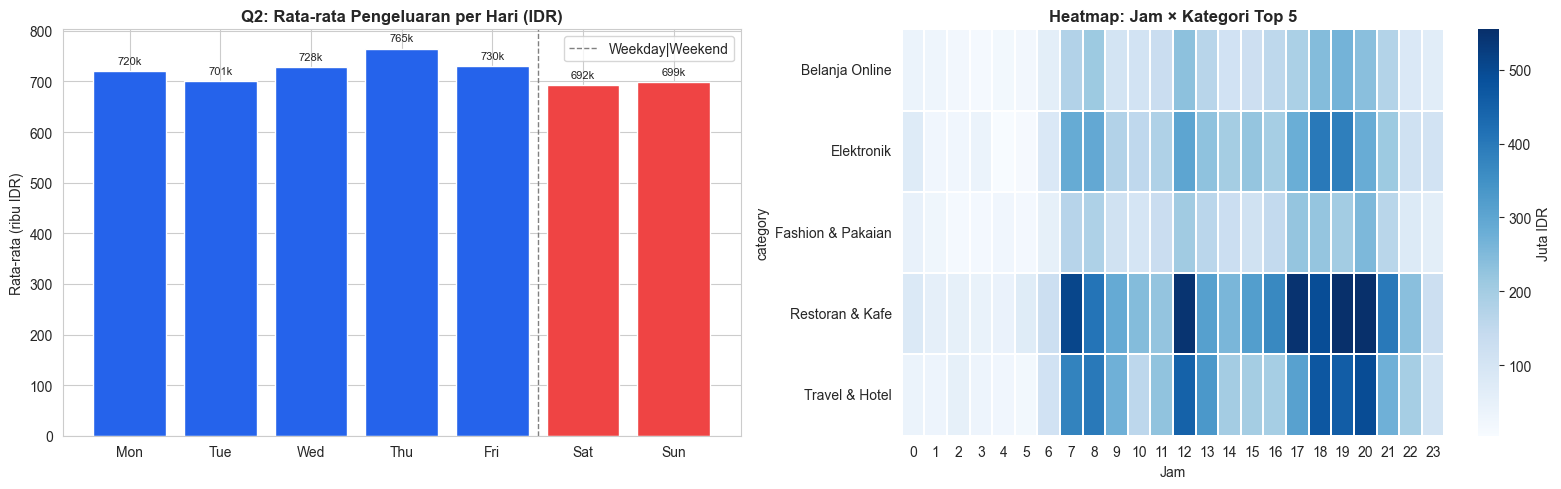


📌 Q2 PREVIEW (diuji di Cell A/B Test):
  Weekend avg: Rp 695,718  |  Weekday avg: Rp 728,657  |  Selisih: -4.5%


In [8]:
# ── Q2: Pola Waktu Pengeluaran ──────────────────────────────
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_avg   = df.groupby('day_name')['amount'].mean().reindex(day_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
bar_c = ['#EF4444' if d in ['Sat','Sun'] else PRIMARY for d in day_order]
axes[0].bar(day_order, day_avg/1e3, color=bar_c)
axes[0].set_ylabel('Rata-rata (ribu IDR)')
axes[0].set_title('Q2: Rata-rata Pengeluaran per Hari (IDR)', fontweight='bold')
axes[0].axvline(4.5, color='gray', ls='--', lw=1, label='Weekday|Weekend')
axes[0].legend()
for i, v in enumerate(day_avg/1e3):
    axes[0].text(i, v+v*0.02, f'{v:.0f}k', ha='center', fontsize=8)

top5 = df.groupby('category')['amount'].sum().nlargest(5).index
hm   = (df[df['category'].isin(top5)]
        .groupby(['hour','category'])['amount'].sum().unstack(fill_value=0))
sns.heatmap(hm.T/1e6, cmap='Blues', ax=axes[1],
            linewidths=0.3, cbar_kws={'label':'Juta IDR'})
axes[1].set_title('Heatmap: Jam × Kategori Top 5', fontweight='bold')
axes[1].set_xlabel('Jam')
plt.tight_layout(); plt.show()

wknd = day_avg[['Sat','Sun']].mean()
wkdy = day_avg[['Mon','Tue','Wed','Thu','Fri']].mean()
diff = (wknd-wkdy)/wkdy*100
print(f'\n📌 Q2 PREVIEW (diuji di Cell A/B Test):')
print(f'  Weekend avg: Rp {wknd:,.0f}  |  Weekday avg: Rp {wkdy:,.0f}  |  Selisih: {diff:+.1f}%')

### Cell 9 — Q3: Anomali Bulanan

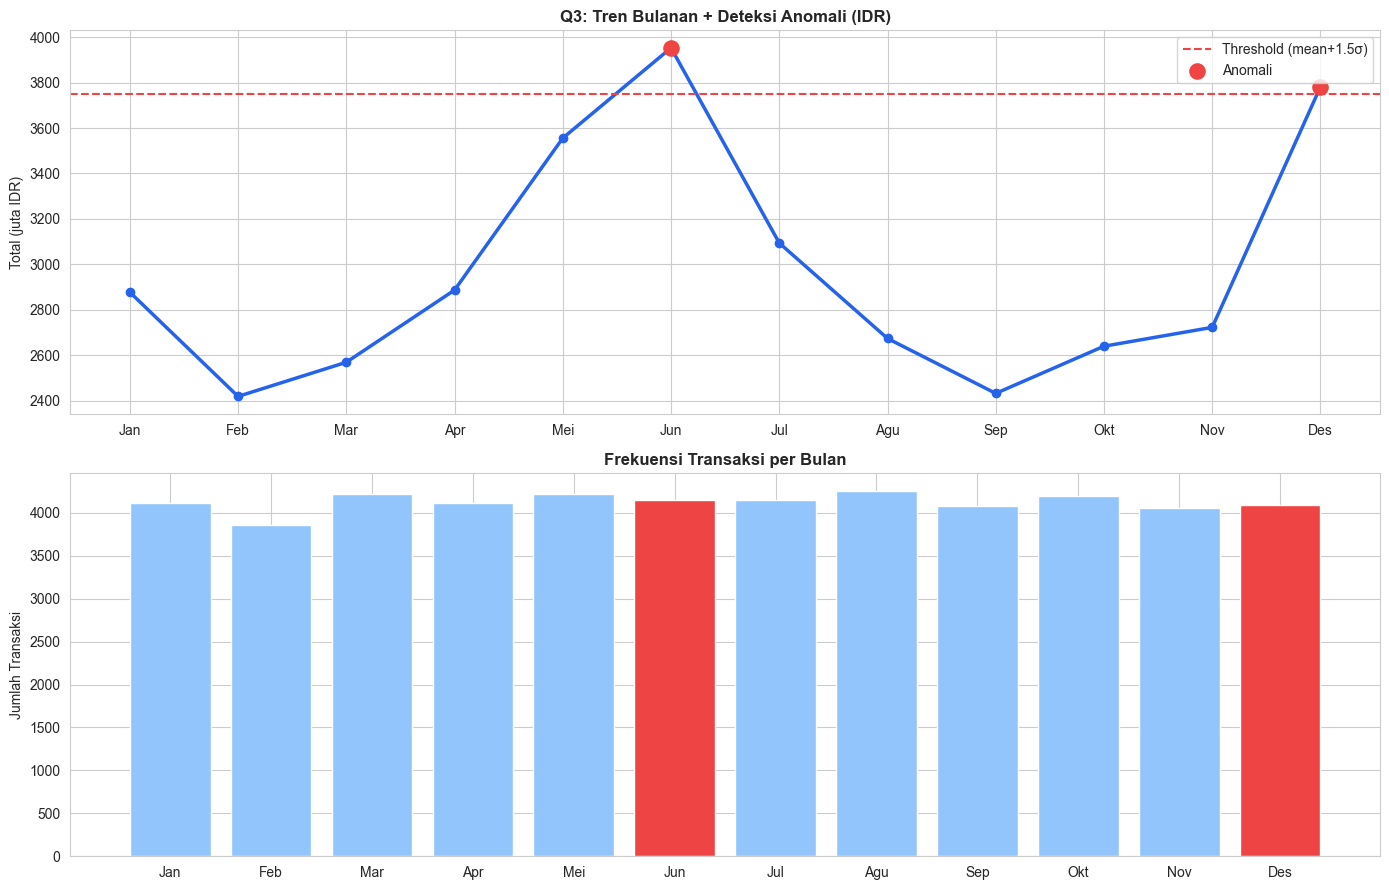


📌 Q3 ANSWER:
  Bulan anomali : ['Jun', 'Des']
  Threshold IDR : Rp 3751.6 juta/bulan
  ➡️  BUDU: tandai di Weekly Reflection sebagai periode risiko tinggi


In [9]:
# ── Q3: Anomali Bulanan ─────────────────────────────────────
monthly = (df.groupby('month')['amount']
             .agg(total='sum', count='count', avg='mean').reset_index())
thr              = monthly['total'].mean() + ANOMALY_STD_FACTOR * monthly['total'].std()
monthly['anomaly'] = monthly['total'] > thr
m_lbl = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, axes = plt.subplots(2, 1, figsize=(14,9))
axes[0].plot(monthly['month'], monthly['total']/1e6, marker='o', color=PRIMARY, lw=2.5)
axes[0].axhline(thr/1e6, color=WARN, ls='--', lw=1.5, label=f'Threshold (mean+{ANOMALY_STD_FACTOR}σ)')
anom = monthly[monthly['anomaly']]
axes[0].scatter(anom['month'], anom['total']/1e6, color=WARN, s=120, zorder=5, label='Anomali')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(m_lbl)
axes[0].set_ylabel('Total (juta IDR)'); axes[0].legend()
axes[0].set_title('Q3: Tren Bulanan + Deteksi Anomali (IDR)', fontweight='bold')
axes[1].bar(monthly['month'], monthly['count'],
            color=['#EF4444' if a else '#93C5FD' for a in monthly['anomaly']])
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(m_lbl)
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_title('Frekuensi Transaksi per Bulan', fontweight='bold')
plt.tight_layout(); plt.show()

anom_names = [m_lbl[m-1] for m in anom['month'].tolist()]
print(f'\n📌 Q3 ANSWER:')
print(f'  Bulan anomali : {anom_names if anom_names else "Tidak ada"}')
print(f'  Threshold IDR : Rp {thr/1e6:.1f} juta/bulan')
print('  ➡️  BUDU: tandai di Weekly Reflection sebagai periode risiko tinggi')

### Cell 10 — Q4: Money Leak Detection

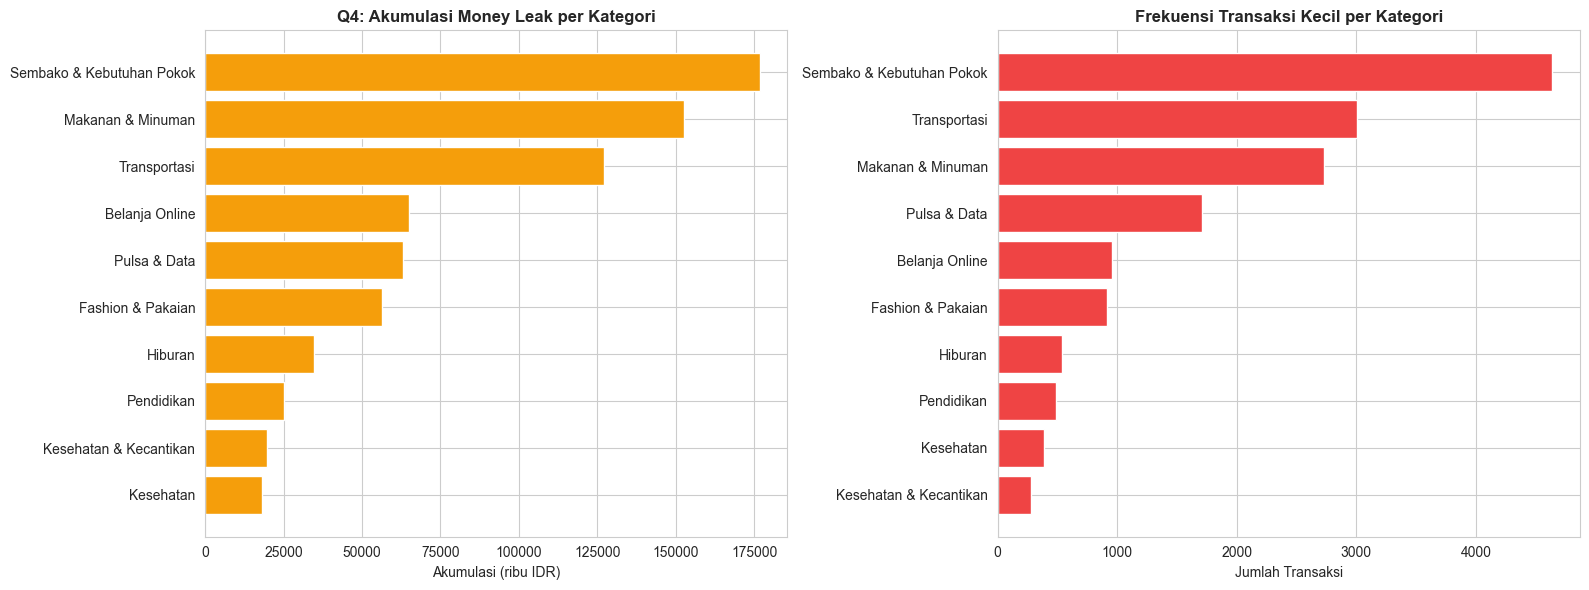


📌 Q4 ANSWER:
  Batas transaksi "kecil" : ≤ Rp 99,650
  Total bocor             : Rp 741.7 juta
  ⚠️  Sembako & Kebutuhan Pokok: 386.5×/bln · akumulasi Rp 176,812k
  ⚠️  Makanan & Minuman: 227.3×/bln · akumulasi Rp 152,664k
  ⚠️  Transportasi: 250.2×/bln · akumulasi Rp 127,312k
  ⚠️  Belanja Online: 79.5×/bln · akumulasi Rp 64,907k
  ⚠️  Pulsa & Data: 142.4×/bln · akumulasi Rp 63,224k
  ➡️  BUDU: tampilkan kartu "Silent Money Leak" untuk kategori ini


In [10]:
# ── Q4: Money Leak Detection ────────────────────────────────
median_idr = df['amount'].median()
small_lim  = median_idr * SMALL_TXN_MULTIPLIER
df_small   = df[df['amount'] <= small_lim]
n_months   = max(df['month'].nunique(), 1)

leak = (df_small.groupby('category')
        .agg(total_idr=('amount','sum'), freq=('amount','count'), avg_idr=('amount','mean'))
        .assign(freq_monthly=lambda x: x['freq']/n_months)
        .query(f'freq_monthly >= {FREQ_MONTH_THRESH}')
        .sort_values('total_idr', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16,6))
if not leak.empty:
    lt = leak.sort_values('total_idr')
    axes[0].barh(lt.index, lt['total_idr']/1e3, color='#F59E0B')
    axes[1].barh(leak.sort_values('freq').index, leak.sort_values('freq')['freq'], color=WARN)
else:
    leak_all = (df_small.groupby('category')
                .agg(total_idr=('amount','sum'), freq=('amount','count'))
                .sort_values('total_idr', ascending=False).head(10))
    axes[0].barh(leak_all.index[::-1], leak_all['total_idr'][::-1]/1e3, color='#F59E0B')
    axes[1].barh(leak_all.index[::-1], leak_all['freq'][::-1], color=WARN)
axes[0].set_title('Q4: Akumulasi Money Leak per Kategori', fontweight='bold')
axes[0].set_xlabel('Akumulasi (ribu IDR)')
axes[1].set_title('Frekuensi Transaksi Kecil per Kategori', fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi')
plt.tight_layout(); plt.show()

print(f'\n📌 Q4 ANSWER:')
print(f'  Batas transaksi "kecil" : ≤ Rp {small_lim:,.0f}')
print(f'  Total bocor             : Rp {df_small["amount"].sum()/1e6:,.1f} juta')
if not leak.empty:
    for cat, row in leak.head(5).iterrows():
        print(f'  ⚠️  {cat}: {row["freq_monthly"]:.1f}×/bln · akumulasi Rp {row["total_idr"]/1e3:,.0f}k')
print('  ➡️  BUDU: tampilkan kartu "Silent Money Leak" untuk kategori ini')

### Cell 11 — Q5: Metode Pembayaran + Spearman

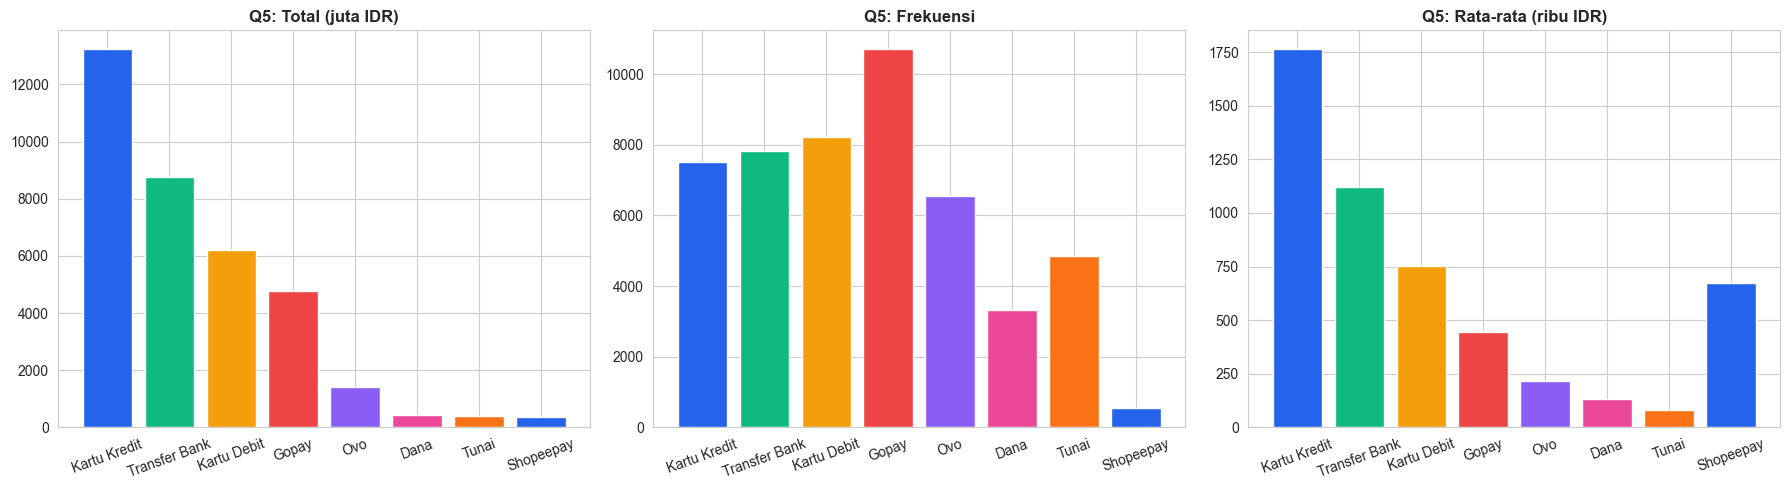


📌 Q5 ANSWER:
  Spearman ρ: 0.0043  |  p-value: 0.3380
  ℹ️  Korelasi lemah (ρ=0.00 < 0.3)


,total,count,avg
payment_method,,,
Kartu Kredit,13229972300,7504,"1,763,056.01"
Transfer Bank,8769664400,7812,"1,122,588.89"
Kartu Debit,6207856800,8222,"755,030.02"
Gopay,4779641700,10703,"446,570.28"
Ovo,1411488000,6555,"215,329.98"
Dana,444332600,3320,"133,835.12"
Tunai,398497300,4847,"82,215.25"
Shopeepay,364662600,540,"675,301.11"


In [11]:
# ── Q5: Metode Pembayaran + Spearman ────────────────────────
pay = (df.groupby('payment_method')['amount']
         .agg(total='sum', count='count', avg='mean')
         .sort_values('total', ascending=False))
pay_enc = df['payment_method'].astype('category').cat.codes
rho, pval = spearmanr(pay_enc, df['amount'])

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, (col, lbl, div) in enumerate([
        ('total','Total (juta IDR)',1e6),
        ('count','Frekuensi',1),
        ('avg','Rata-rata (ribu IDR)',1e3)]):
    axes[i].bar(pay.index, pay[col]/div, color=PALETTE[:len(pay)])
    axes[i].set_title(f'Q5: {lbl}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print(f'\n📌 Q5 ANSWER:')
print(f'  Spearman ρ: {rho:.4f}  |  p-value: {pval:.4f}')
if abs(rho) >= 0.3:
    print(f'  ✅ Korelasi signifikan (ρ={rho:.2f} ≥ 0.3)')
    print('  ➡️  BUDU: sesuaikan konteks peringatan berdasarkan metode bayar')
else:
    print(f'  ℹ️  Korelasi lemah (ρ={rho:.2f} < 0.3)')
display(pay.head(10))

### Cell 12 — EDA per Segmen Sosio-Ekonomi

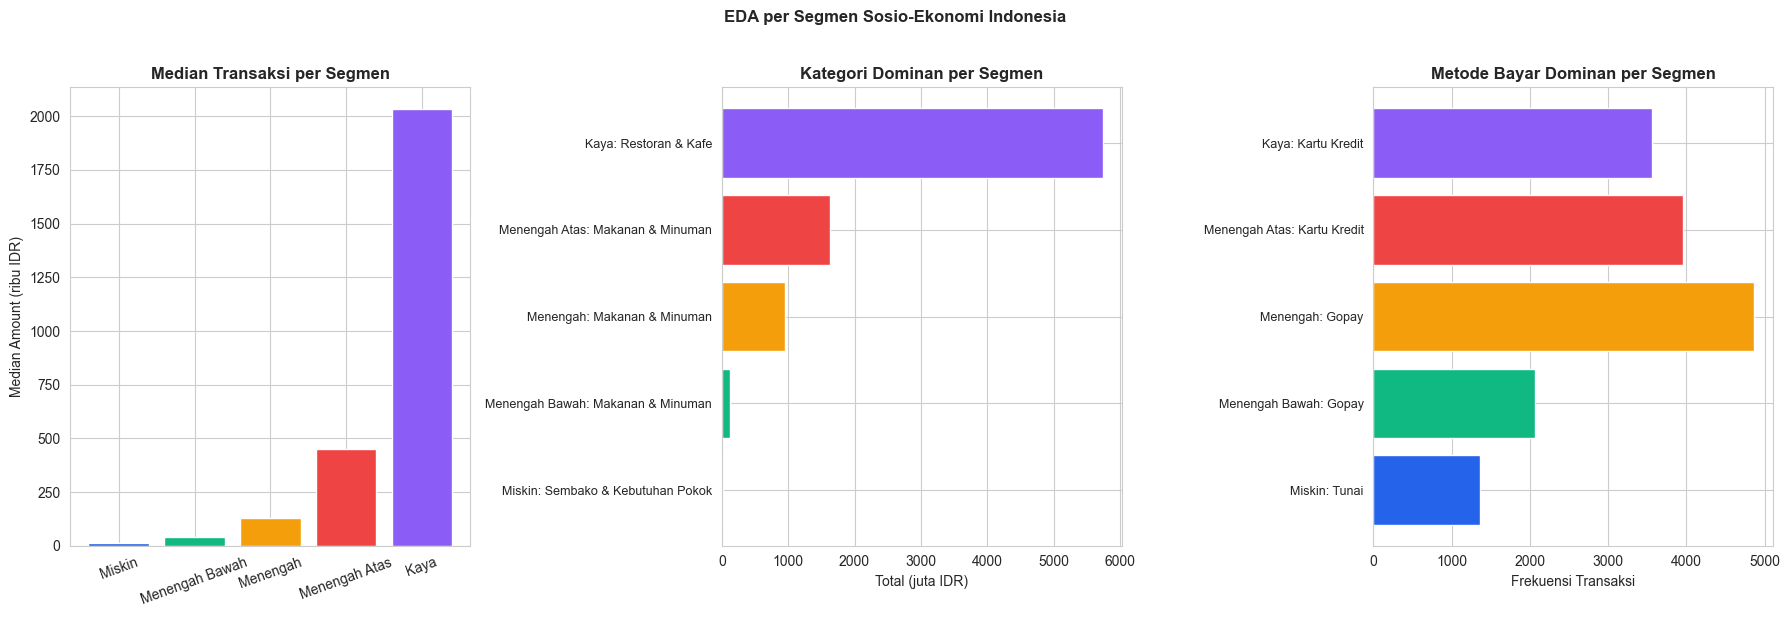

Median amount per segmen:
  Kelas E (Miskin)                   : Rp     15,000  (2,475 txn)
  Kelas D (Menengah Bawah)           : Rp     41,000  (6,725 txn)
  Kelas C (Menengah)                 : Rp    130,900  (19,208 txn)
  Kelas B (Menengah Atas)            : Rp    448,400  (13,184 txn)
  Kelas A (Kaya)                     : Rp  2,032,700  (7,911 txn)


In [12]:
# ── EDA Segmen Sosio-Ekonomi ────────────────────────────────
seg_order = ['Kelas E (Miskin)','Kelas D (Menengah Bawah)',
             'Kelas C (Menengah)','Kelas B (Menengah Atas)','Kelas A (Kaya)']
seg_avail = [s for s in seg_order if s in df['segmen_label'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

seg_med = df.groupby('segmen_label')['amount'].median().reindex(seg_avail)
axes[0].bar(range(len(seg_med)), seg_med.values/1e3, color=PALETTE[:len(seg_med)])
axes[0].set_xticks(range(len(seg_med)))
axes[0].set_xticklabels([s.split('(')[1].rstrip(')') for s in seg_avail], rotation=20)
axes[0].set_ylabel('Median Amount (ribu IDR)')
axes[0].set_title('Median Transaksi per Segmen', fontweight='bold')

top_cat = df.groupby(['segmen_label','category'])['amount'].sum().reset_index()
top_cat = top_cat.sort_values('amount', ascending=False)
top_cat = top_cat.groupby('segmen_label').first().reindex(seg_avail)
axes[1].barh(range(len(top_cat)), top_cat['amount'].values/1e6, color=PALETTE[:len(top_cat)])
axes[1].set_yticks(range(len(top_cat)))
axes[1].set_yticklabels([f'{s.split("(")[1].rstrip(")")}: {c}'
                          for s, c in zip(top_cat.index, top_cat['category'])], fontsize=9)
axes[1].set_xlabel('Total (juta IDR)')
axes[1].set_title('Kategori Dominan per Segmen', fontweight='bold')

pay_seg = df.groupby(['segmen_label','payment_method'])['amount'].count().reset_index()
pay_seg = pay_seg.sort_values('amount', ascending=False)
top_pay = pay_seg.groupby('segmen_label').first().reindex(seg_avail)
axes[2].barh(range(len(top_pay)), top_pay['amount'].values, color=PALETTE[:len(top_pay)])
axes[2].set_yticks(range(len(top_pay)))
axes[2].set_yticklabels([f'{s.split("(")[1].rstrip(")")}: {p}'
                          for s, p in zip(top_pay.index, top_pay['payment_method'])], fontsize=9)
axes[2].set_xlabel('Frekuensi Transaksi')
axes[2].set_title('Metode Bayar Dominan per Segmen', fontweight='bold')

plt.suptitle('EDA per Segmen Sosio-Ekonomi Indonesia', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('Median amount per segmen:')
for seg in seg_avail:
    med = df[df['segmen_label']==seg]['amount'].median()
    cnt = (df['segmen_label']==seg).sum()
    print(f'  {seg:35s}: Rp {med:>10,.0f}  ({cnt:,} txn)')

---
## 🧪 BAGIAN G — A/B Testing

### Cell 13 — Mann-Whitney U: Weekend vs Weekday

🧪 A/B TEST — Weekend vs Weekday · BUDU · IDR
  Grup A (Weekend) n=14,089  Mean: Rp 695,733  Median: Rp 202,300
  Grup B (Weekday) n=35,414  Mean: Rp 728,637  Median: Rp 198,500
  Selisih mean   : -4.5%  (threshold Q2: ≥ +20%)
  Mann-Whitney U : 250,415,930
  p-value        : 0.255721
  Effect size r  : 0.0030  (kecil<0.1 | sedang 0.1–0.3 | besar>0.3)

  ℹ️  Gagal tolak H0 (p=0.2557 ≥ 0.05)


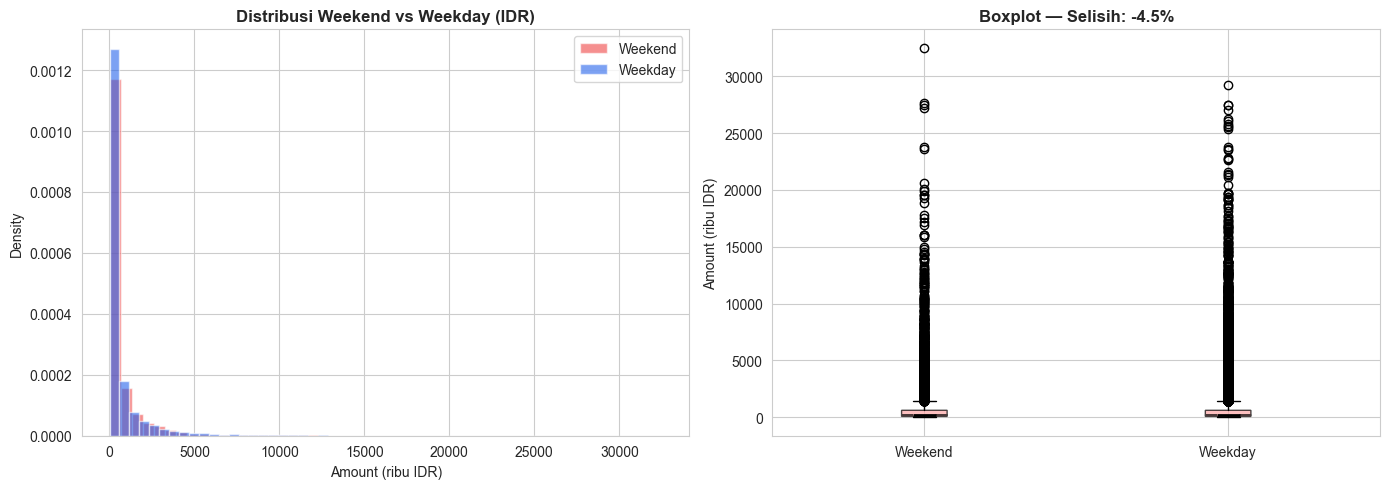

In [13]:
# ============================================================
# CELL 13 — A/B Testing · Q2 BUDU · Mann-Whitney U
# H0: Tidak ada perbedaan rata-rata pengeluaran weekend vs weekday
# H1: Pengeluaran weekend ≥ 20% lebih tinggi dari weekday
# Uji: Mann-Whitney U (non-parametrik)  |  α = 0.05
# ============================================================
grp_w = df[df['is_weekend']==1]['amount']
grp_d = df[df['is_weekend']==0]['amount']

u_stat, p_val = mannwhitneyu(grp_w, grp_d, alternative='greater')
n_total  = len(grp_w) + len(grp_d)
z_score  = stats.norm.ppf(1 - p_val)
effect_r = z_score / np.sqrt(n_total)
pct_diff = (grp_w.mean() - grp_d.mean()) / grp_d.mean() * 100
alpha = 0.05; thr_pct = 20

print('='*65)
print('🧪 A/B TEST — Weekend vs Weekday · BUDU · IDR')
print('='*65)
print(f'  Grup A (Weekend) n={len(grp_w):,}  Mean: Rp {grp_w.mean():,.0f}  Median: Rp {grp_w.median():,.0f}')
print(f'  Grup B (Weekday) n={len(grp_d):,}  Mean: Rp {grp_d.mean():,.0f}  Median: Rp {grp_d.median():,.0f}')
print(f'  Selisih mean   : {pct_diff:+.1f}%  (threshold Q2: ≥ +{thr_pct}%)')
print(f'  Mann-Whitney U : {u_stat:,.0f}')
print(f'  p-value        : {p_val:.6f}')
print(f'  Effect size r  : {effect_r:.4f}  (kecil<0.1 | sedang 0.1–0.3 | besar>0.3)')
print()

if p_val < alpha and pct_diff >= thr_pct:
    print(f'  ✅ TOLAK H0 — signifikan DAN selisih ≥ {thr_pct}%')
    print('  📌 BUDU: aktifkan Smart Warning otomatis setiap Jumat malam')
elif p_val < alpha:
    print(f'  ⚠️  Signifikan statistik, tapi selisih {pct_diff:.1f}% < {thr_pct}%')
else:
    print(f'  ℹ️  Gagal tolak H0 (p={p_val:.4f} ≥ {alpha})')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for g, lbl, clr in [(grp_w,'Weekend',WARN),(grp_d,'Weekday',PRIMARY)]:
    axes[0].hist(g/1e3, bins=50, alpha=0.6, label=lbl, color=clr, density=True)
axes[0].set_xlabel('Amount (ribu IDR)'); axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi Weekend vs Weekday (IDR)', fontweight='bold')
axes[0].legend()
axes[1].boxplot([grp_w/1e3, grp_d/1e3], labels=['Weekend','Weekday'],
                patch_artist=True, notch=True,
                boxprops=dict(facecolor='#FCA5A5', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_ylabel('Amount (ribu IDR)')
axes[1].set_title(f'Boxplot — Selisih: {pct_diff:+.1f}%', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🔧 BAGIAN H — Feature Engineering

### Cell 14 — Feature Engineering Level Transaksi

In [14]:
# ============================================================
# CELL 14 — Feature Engineering Level Transaksi
# ============================================================

bins_idr = [0, 50_000, 200_000, 500_000, 1_000_000, float('inf')]
lbl_idr  = ['<50k','50k-200k','200k-500k','500k-1jt','>1jt']
df['amount_idr_bucket'] = pd.cut(df['amount'], bins=bins_idr, labels=lbl_idr)

df['above_avg'] = (df['amount'] > df['amount'].mean()).astype(int)

cat_freq = df['category'].value_counts(normalize=True).to_dict()
df['category_freq_enc'] = df['category'].map(cat_freq)

if 'dist_user_merchant' not in df.columns:
    df['dist_user_merchant'] = 0.0

df['age_group'] = pd.cut(df['usia'].fillna(25),
                          bins=[0,17,24,34,44,99],
                          labels=['<18','18-24','25-34','35-44','45+'])

df_s = df.sort_values(['user_id','date']).copy()
df_s['amount_lag1']    = df_s.groupby('user_id')['amount'].shift(1)
df_s['amount_diff']    = (df_s['amount'] - df_s['amount_lag1']).fillna(0)
df_s['rolling_7txn']   = (df_s.groupby('user_id')['amount']
                           .transform(lambda x: x.rolling(7, min_periods=1).sum()))
df_s['rolling_30txn']  = (df_s.groupby('user_id')['amount']
                           .transform(lambda x: x.rolling(30, min_periods=1).sum()))
df_s['rolling_7_mean'] = (df_s.groupby('user_id')['amount']
                           .transform(lambda x: x.rolling(7, min_periods=1).mean()))
df_s['is_spike'] = (df_s['amount'] > df_s['rolling_7_mean'] * 2).astype(int)
df = df_s.reset_index(drop=True)

print('✅ Feature Engineering Level Transaksi:')
feats = ['amount_idr_bucket','above_avg','category_freq_enc',
         'dist_user_merchant','age_group','amount_lag1','amount_diff',
         'rolling_7txn','rolling_30txn','is_spike']
for f in feats:
    print(f'  {f:30s} → {df[f].dtype}')

✅ Feature Engineering Level Transaksi:
  amount_idr_bucket              → category
  above_avg                      → int64
  category_freq_enc              → float64
  dist_user_merchant             → float64
  age_group                      → category
  amount_lag1                    → float64
  amount_diff                    → float64
  rolling_7txn                   → float64
  rolling_30txn                  → float64
  is_spike                       → int64


### Cell 15 — Feature Engineering Level User

✅ User Profiles: 1000 user × 47 fitur
  Range impulse_score: 0.052 – 0.395
  Avg total spending : Rp 35,606,116
  pendapatan_bulan   : Rp 800,650 – Rp 143,899,340


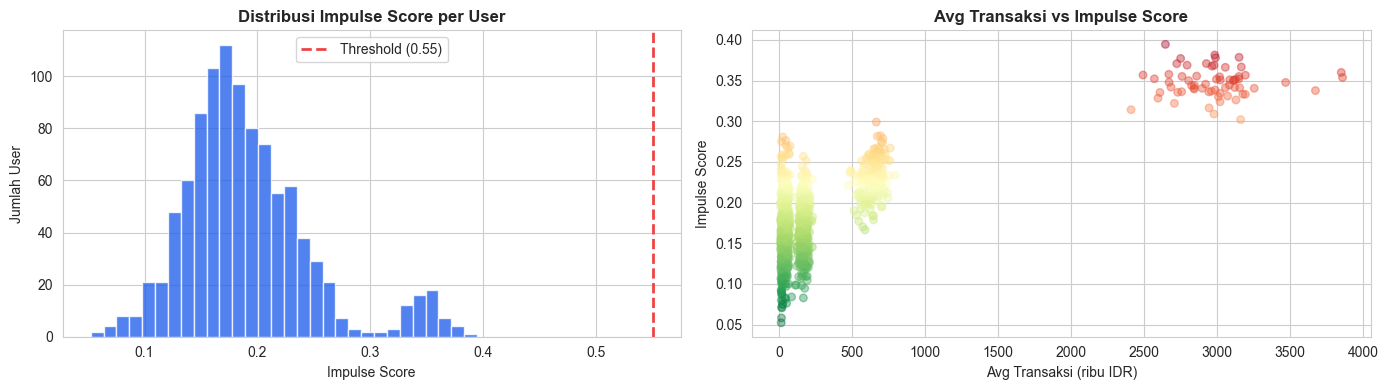

In [15]:
# ============================================================
# CELL 15 — Feature Engineering Level USER
# ============================================================
user_agg = df.groupby('user_id').agg(
    total_spending_idr  = ('amount',      'sum'),
    avg_txn_idr         = ('amount',      'mean'),
    median_txn_idr      = ('amount',      'median'),
    max_txn_idr         = ('amount',      'max'),
    txn_count           = ('amount',      'count'),
    std_amount_idr      = ('amount',      'std'),
    weekend_ratio       = ('is_weekend',  'mean'),
    night_ratio         = ('is_night',    'mean'),
    month_start_ratio   = ('is_month_start','mean'),
    month_end_ratio     = ('is_month_end', 'mean'),
    above_avg_ratio     = ('above_avg',   'mean'),
    spike_ratio         = ('is_spike',    'mean'),
    unique_categories   = ('category',    'nunique'),
    unique_merchants    = ('sub_category','nunique'),
    active_months       = ('month',       'nunique'),
    fraud_ratio         = ('is_fraud',    'mean'),
    avg_dist_merchant   = ('dist_user_merchant','mean'),
).reset_index()

user_agg['std_amount_idr'].fillna(0, inplace=True)
user_agg['spending_cov'] = (
    user_agg['std_amount_idr'] /
    user_agg['avg_txn_idr'].replace(0, np.nan)).fillna(0)
user_agg['impulse_score'] = (
    user_agg['weekend_ratio']   * 0.35 +
    user_agg['night_ratio']     * 0.30 +
    user_agg['above_avg_ratio'] * 0.20 +
    user_agg['spike_ratio']     * 0.15).round(4)

cat_pivot = (df.pivot_table(index='user_id', columns='category',
                             values='amount', aggfunc='sum', fill_value=0))
cat_pivot.columns = [f'cat_{str(c).lower().replace(" & ","_").replace(" ","_")[:18]}'
                     for c in cat_pivot.columns]

pay_dom = (df.groupby('user_id')['payment_method']
             .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown')
             .reset_index().rename(columns={'payment_method':'dominant_payment'}))

gender_agg = df.groupby('user_id')['gender'].agg(
    lambda x: x.mode().iloc[0] if len(x)>0 else 'Unknown').reset_index()
age_agg    = df.groupby('user_id')['usia'].mean().reset_index().rename(columns={'usia':'age'})

# Merge pendapatan_bulan dari df_users
income_agg = df_users[['user_id','pendapatan_bulan','spending_ratio',
                        'segmen','segmen_label','kota','tier_kota','populasi_kota']]

user_features = (user_agg
                 .merge(cat_pivot,   on='user_id', how='left')
                 .merge(pay_dom,     on='user_id', how='left')
                 .merge(gender_agg,  on='user_id', how='left')
                 .merge(age_agg,     on='user_id', how='left')
                 .merge(income_agg,  on='user_id', how='left'))

user_features.fillna(0, inplace=True)

print(f'✅ User Profiles: {user_features.shape[0]} user × {user_features.shape[1]} fitur')
print(f'  Range impulse_score: {user_features["impulse_score"].min():.3f} – {user_features["impulse_score"].max():.3f}')
print(f'  Avg total spending : Rp {user_features["total_spending_idr"].mean():,.0f}')
print(f'  pendapatan_bulan   : Rp {user_features["pendapatan_bulan"].min():,.0f} – Rp {user_features["pendapatan_bulan"].max():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].hist(user_features['impulse_score'], bins=30, color=PRIMARY, alpha=0.8, edgecolor='white')
axes[0].axvline(IMPULSE_THRESHOLD, color=WARN, ls='--', lw=2, label=f'Threshold ({IMPULSE_THRESHOLD})')
axes[0].set_xlabel('Impulse Score'); axes[0].set_ylabel('Jumlah User')
axes[0].set_title('Distribusi Impulse Score per User', fontweight='bold')
axes[0].legend()
axes[1].scatter(user_features['avg_txn_idr']/1e3, user_features['impulse_score'],
                alpha=0.4, c=user_features['impulse_score'], cmap='RdYlGn_r', s=30)
axes[1].set_xlabel('Avg Transaksi (ribu IDR)'); axes[1].set_ylabel('Impulse Score')
axes[1].set_title('Avg Transaksi vs Impulse Score', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🤖 BAGIAN I — Spending Personality Clustering

### Cell 16 — Elbow + Silhouette

✅ pendapatan_bulan tersedia: min=Rp 800,650 | max=Rp 143,899,340
Fitur aktif: 15 kolom
  ✅ Tidak ada null di fitur


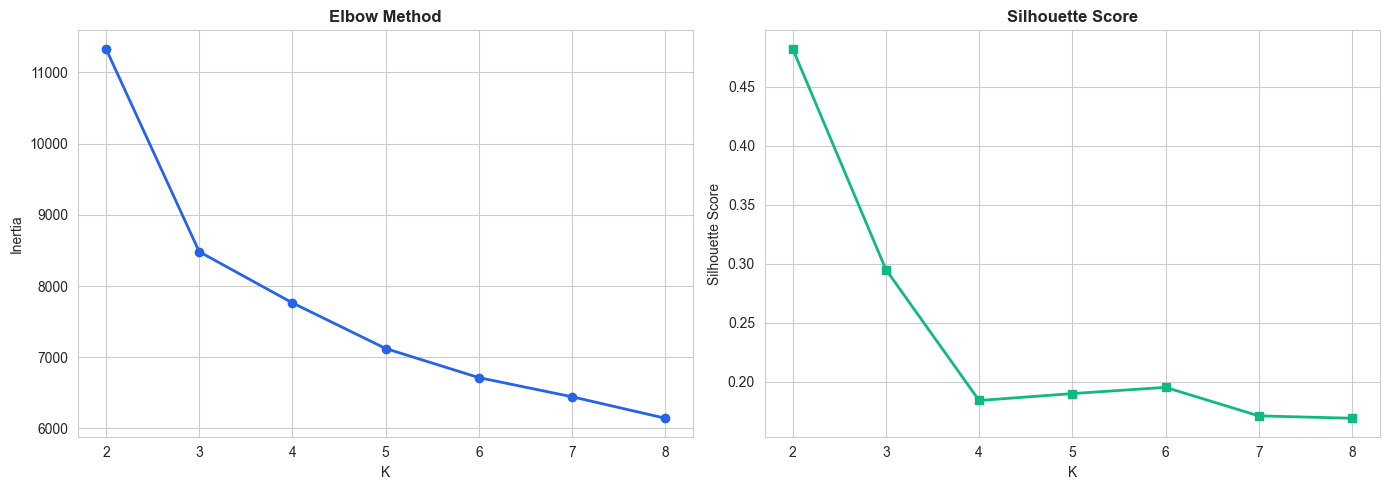

✅ K terbaik: 2  (Silhouette: 0.4823)


In [16]:
# ============================================================
# CELL 16 — Pilih K Optimal (Elbow + Silhouette)
# Feature v3 — 20 fitur bersih (cleanup + pendapatan_bulan)
# ============================================================

# === STEP 1: Transformasi cat_* ke rasio proporsi (HARUS SEBELUM drop total_spending) ===
cat_cols_src = [c for c in user_features.columns
                if c.startswith('cat_') and not c.endswith('_ratio')]
for col in cat_cols_src:
    ratio_col = col + '_ratio'
    user_features[ratio_col] = (
        user_features[col] / user_features['total_spending_idr'].replace(0, np.nan)
    ).fillna(0)

all_cat_raw = [c for c in user_features.columns
               if c.startswith('cat_') and not c.endswith('_ratio')]
user_features.drop(columns=all_cat_raw, inplace=True)

# === STEP 2: Hapus fitur tidak relevan ===
drop_irrelevant = [
    'fraud_ratio', 'avg_dist_merchant', 'active_months',
    'month_start_ratio', 'month_end_ratio',
]
drop_irrelevant = [c for c in drop_irrelevant if c in user_features.columns]
user_features.drop(columns=drop_irrelevant, inplace=True)

# === STEP 3: Hapus fitur redundan ===
drop_redundant = [
    'median_txn_idr', 'total_spending_idr', 'max_txn_idr',
    'std_amount_idr', 'unique_merchants',
]
drop_redundant = [c for c in drop_redundant if c in user_features.columns]
user_features.drop(columns=drop_redundant, inplace=True)

# === STEP 4: Pastikan pendapatan_bulan tersedia (fallback Kaggle mode) ===
if 'pendapatan_bulan' not in user_features.columns:
    print("⚠️  pendapatan_bulan tidak ditemukan — diisi 0 (Kaggle mode)")
    user_features['pendapatan_bulan'] = 0
else:
    print(f"✅ pendapatan_bulan tersedia: min=Rp {user_features['pendapatan_bulan'].min():,.0f} | max=Rp {user_features['pendapatan_bulan'].max():,.0f}")

# === STEP 5: Definisi FEATURE_COLS v3 (20 fitur) ===
FEATURE_COLS = [
    # Behavioral Core (9)
    'avg_txn_idr', 'txn_count', 'weekend_ratio', 'night_ratio',
    'above_avg_ratio', 'spike_ratio', 'impulse_score',
    'unique_categories', 'spending_cov',
    # ✨ BARU v3: Variabel Pendapatan (1)
    'pendapatan_bulan',
    # Category Ratios (10)
    'cat_makanan_&_minum_ratio', 'cat_transportasi_ratio',
    'cat_kesehatan_&_kec_ratio', 'cat_sembako_&_kebut_ratio',
    'cat_kesehatan_ratio', 'cat_pendidikan_ratio',
    'cat_belanja_online_ratio', 'cat_pulsa_&_data_ratio',
    'cat_hiburan_ratio', 'cat_fashion_&_pakai_ratio',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in user_features.columns]
print(f'Fitur aktif: {len(FEATURE_COLS)} kolom')

# === VERIFIKASI NULL ===
null_check = user_features[FEATURE_COLS].isnull().sum()
if null_check.sum() > 0:
    print(f"⚠️  Null ditemukan:\n{null_check[null_check > 0]}")
else:
    print("  ✅ Tidak ada null di fitur")

# === DISTRIBUSI pendapatan_bulan per persona (jika sudah ada) ===
if 'spending_persona' in user_features.columns:
    print(f"\nDistribusi pendapatan_bulan per persona:")
    print(user_features.groupby('spending_persona')['pendapatan_bulan']
          .agg(['mean','median','std']).round(0))

X        = user_features[FEATURE_COLS].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(K_range, inertias, marker='o', color=PRIMARY, lw=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[1].plot(K_range, sil_scores, marker='s', color=ACCENT, lw=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'✅ K terbaik: {best_k}  (Silhouette: {max(sil_scores):.4f})')


### Cell 17 — Final Clustering + Label Persona

Statistik cluster:
         avg_impulse      avg_txn  count
cluster                                 
0               0.17    42,240.48    377
1               0.19   310,145.69    559
2               0.35 2,980,857.60     64

📌 Q6 ANSWER — Impulsive Spender (impulse_score ≥ 0.55):
  0/1000 pengguna = 0.0%
  Emotional Spender        :  559 user (55.9%)  avg txn Rp 310,146
  Rational Spender         :  377 user (37.7%)  avg txn Rp 42,240
  Impulsive Spender        :   64 user (6.4%)  avg txn Rp 2,980,858


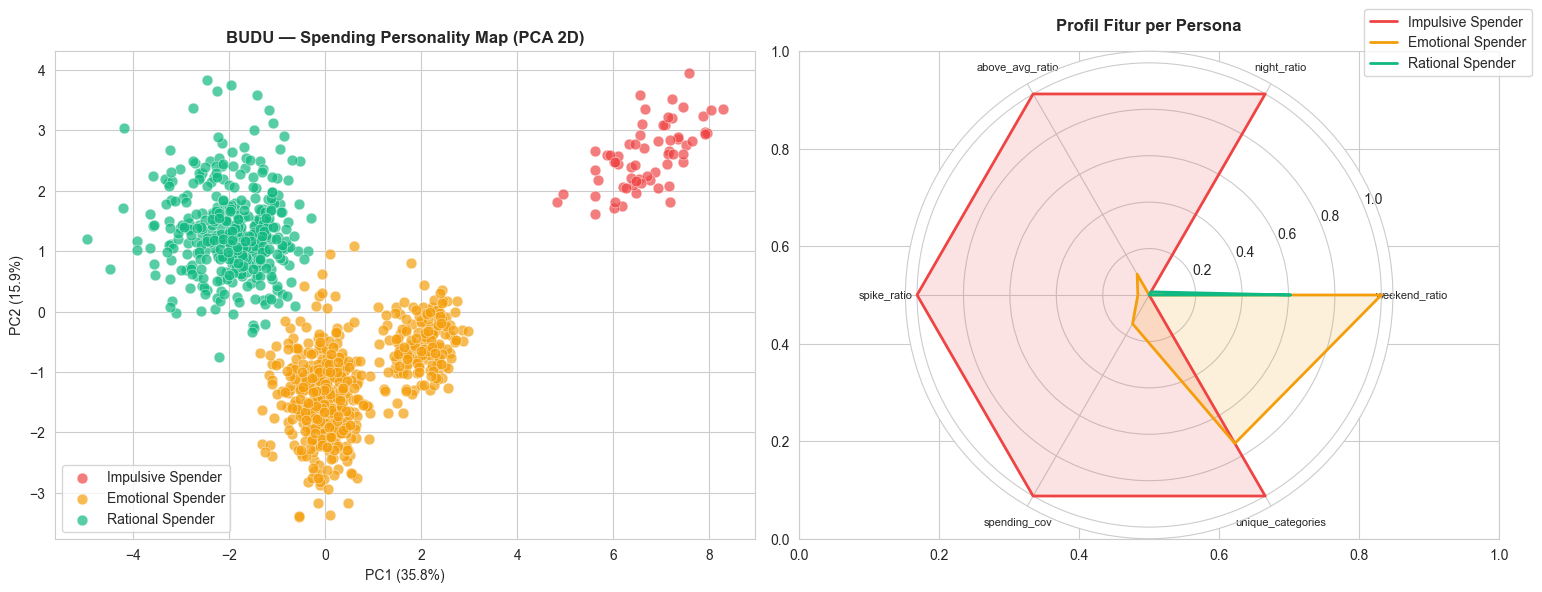

Variance explained PCA: 51.7%


In [17]:
# ============================================================
# CELL 17 — Final Clustering K=3 + Label + Q6 Answer
# ============================================================
K_FINAL  = 3
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

stats_clust = user_features.groupby('cluster').agg(
    avg_impulse = ('impulse_score','mean'),
    avg_txn     = ('avg_txn_idr','mean'),
    count       = ('user_id','count'),
).round(2)
print('Statistik cluster:'); print(stats_clust)

rank = stats_clust['avg_impulse'].rank(method='first').astype(int)
PERSONA_MAP_K3 = {rank.max():'Impulsive Spender',
                  rank.median():'Emotional Spender',
                  rank.min():'Rational Spender'}
user_features['spending_persona'] = user_features['cluster'].map(
    {c: PERSONA_MAP_K3.get(int(r), f'Persona {r}') for c, r in rank.items()})

n_imp = (user_features['impulse_score'] >= IMPULSE_THRESHOLD).sum()
n_tot = len(user_features)
print(f'\n📌 Q6 ANSWER — Impulsive Spender (impulse_score ≥ {IMPULSE_THRESHOLD}):')
print(f'  {n_imp}/{n_tot} pengguna = {n_imp/n_tot*100:.1f}%')
for persona, cnt in user_features['spending_persona'].value_counts().items():
    avg_txn = user_features[user_features['spending_persona']==persona]['avg_txn_idr'].mean()
    print(f'  {persona:25s}: {cnt:4d} user ({cnt/n_tot*100:.1f}%)  avg txn Rp {avg_txn:,.0f}')

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cmap  = {'Impulsive Spender':WARN,'Emotional Spender':'#F59E0B','Rational Spender':ACCENT}

fig, axes = plt.subplots(1, 2, figsize=(16,6))
for persona, color in cmap.items():
    mask = user_features['spending_persona'] == persona
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], label=persona,
                    color=color, alpha=0.7, s=60, edgecolors='white', lw=0.4)
axes[0].set_title('BUDU — Spending Personality Map (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

radar_feats = [f for f in ['weekend_ratio','night_ratio','above_avg_ratio',
               'spike_ratio','spending_cov','unique_categories'] if f in user_features.columns]
persona_means      = user_features.groupby('spending_persona')[radar_feats].mean()
persona_means_norm = (persona_means - persona_means.min()) / (persona_means.max() - persona_means.min() + 1e-9)
angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist() + [0]
ax2 = fig.add_subplot(122, polar=True)
for persona, color in cmap.items():
    if persona in persona_means_norm.index:
        vals = persona_means_norm.loc[persona].tolist() + [persona_means_norm.loc[persona].tolist()[0]]
        ax2.plot(angles, vals, color=color, lw=2, label=persona)
        ax2.fill(angles, vals, color=color, alpha=0.15)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(radar_feats, size=8)
ax2.set_title('Profil Fitur per Persona', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
plt.tight_layout(); plt.show()
print(f'Variance explained PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%')

---
## 🤖 BAGIAN J — Persiapan Data Model TensorFlow

### Cell 18 — Encode + Normalisasi + Split 70/15/15

Encoding Spending Persona:
  0 → Emotional Spender         (559 user | 55.9%)
  1 → Impulsive Spender         (64 user | 6.4%)
  2 → Rational Spender          (377 user | 37.7%)

📦 Data siap untuk TensorFlow:
  X_train : (700, 15)   y_train: (700,)
  X_val   : (150, 15)   y_val  : (150,)
  X_test  : (150, 15)   y_test : (150,)
  Input features : 15
  Output classes : 3 (['Emotional Spender', 'Impulsive Spender', 'Rational Spender'])


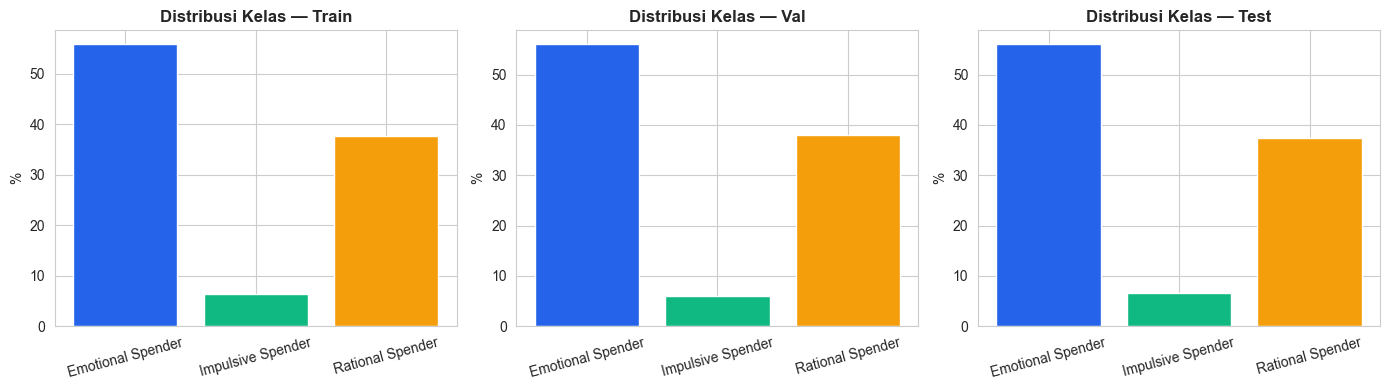

In [18]:
# ============================================================
# CELL 18 — Encode + Normalisasi + Split 70/15/15
# ============================================================
le = LabelEncoder()
user_features['persona_encoded'] = le.fit_transform(user_features['spending_persona'])

print('Encoding Spending Persona:')
for i, cls in enumerate(le.classes_):
    n = (user_features['persona_encoded']==i).sum()
    print(f'  {i} → {cls:25s} ({n} user | {n/len(user_features)*100:.1f}%)')

X_model = user_features[FEATURE_COLS].fillna(0).values
y_model = user_features['persona_encoded'].values

mm     = MinMaxScaler()
X_norm = mm.fit_transform(X_model)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_norm, y_model, test_size=0.30, random_state=42, stratify=y_model)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print(f'\n📦 Data siap untuk TensorFlow:')
print(f'  X_train : {X_tr.shape}   y_train: {y_tr.shape}')
print(f'  X_val   : {X_val.shape}   y_val  : {y_val.shape}')
print(f'  X_test  : {X_te.shape}   y_test : {y_te.shape}')
print(f'  Input features : {X_tr.shape[1]}')
print(f'  Output classes : {len(le.classes_)} ({list(le.classes_)})')

fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, y, lbl in [(axes[0],y_tr,'Train'),(axes[1],y_val,'Val'),(axes[2],y_te,'Test')]:
    uniq, cnt = np.unique(y, return_counts=True)
    ax.bar([le.classes_[i] for i in uniq], cnt/cnt.sum()*100, color=PALETTE[:len(uniq)])
    ax.set_title(f'Distribusi Kelas — {lbl}', fontweight='bold')
    ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

---
## 💡 BAGIAN K — Saran untuk Tim AI Engineer

### Cell 19 — Arsitektur TF + Tools Lengkap

In [19]:
# ============================================================
# CELL 19 — Saran Lengkap untuk Tim AI Engineer
# ============================================================
n_features = len(FEATURE_COLS)

SEP = '='*65
print(SEP)
print('PANDUAN TIM AI ENGINEER - BUDU SPENDING PERSONA')
print(SEP)
print('TASK   : Multi-class Classification (Spending Persona)')
print(f'INPUT  : {n_features} fitur numerik (MinMaxScaler 0-1)')
print('OUTPUT : 3 kelas - Rational / Emotional / Impulsive Spender')
print('TARGET : Accuracy >= 85%, MAE <= 0.02')
print()
print('DISTRIBUSI KELAS:')
for persona, cnt in user_features['spending_persona'].value_counts().items():
    print(f'  {persona:25s}: {cnt} ({cnt/len(user_features)*100:.1f}%)')

print()
print(SEP)
print('ARSITEKTUR TENSORFLOW (copy ke notebook AI)')
print(SEP)
arch = [
    'import tensorflow as tf',
    'from tensorflow import keras',
    'from tensorflow.keras import layers',
    '',
    'N_FEATURES = ' + str(n_features) + '  # update sesuai FEATURE_COLS',
    '',
    '# --- CUSTOM LAYER ---',
    'class BehaviorNormLayer(keras.layers.Layer):',
    '    def build(self, input_shape):',
    '        self.scale = self.add_weight(shape=(input_shape[-1],), initializer="ones", trainable=True)',
    '        self.bias  = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)',
    '    def call(self, x):',
    '        return tf.nn.tanh(x * self.scale + self.bias)',
    '',
    '# --- CUSTOM CALLBACK ---',
    'class EarlyStopOnAccuracy(keras.callbacks.Callback):',
    '    def __init__(self, target=0.85): self.target = target',
    '    def on_epoch_end(self, epoch, logs=None):',
    '        if logs.get("val_accuracy", 0) >= self.target:',
    '            self.model.stop_training = True',
    '',
    '# --- CUSTOM LOSS: Focal Loss ---',
    'class FocalLoss(keras.losses.Loss):',
    '    def __init__(self, gamma=2.0, **kw): super().__init__(**kw); self.gamma = gamma',
    '    def call(self, y_true, y_pred):',
    '        y_oh = tf.one_hot(tf.cast(y_true, tf.int32), 3)',
    '        ce   = -tf.reduce_sum(y_oh * tf.math.log(y_pred + 1e-7), axis=-1)',
    '        p_t  = tf.reduce_sum(y_oh * y_pred, axis=-1)',
    '        return tf.reduce_mean((1 - p_t) ** self.gamma * ce)',
    '',
    '# --- FUNCTIONAL API ---',
    'inputs = keras.Input(shape=(N_FEATURES,), name="spending_features")',
    'x = BehaviorNormLayer(name="behavior_norm")(inputs)',
    'x = layers.Dense(128, activation="relu")(x)',
    'x = layers.BatchNormalization()(x)',
    'x = layers.Dropout(0.30)(x)',
    'x = layers.Dense(64, activation="relu")(x)',
    'x = layers.BatchNormalization()(x)',
    'x = layers.Dropout(0.20)(x)',
    'x = layers.Dense(32, activation="relu")(x)',
    'out = layers.Dense(3, activation="softmax", name="persona")(x)',
    'model = keras.Model(inputs, out, name="BUDU_SpendingPersona")',
    'model.compile(optimizer=keras.optimizers.Adam(1e-3),',
    '              loss=FocalLoss(gamma=2.0), metrics=["accuracy"])',
]
for ln in arch: print(ln)

print()
print(SEP)
print(f'FITUR INPUT MODEL ({n_features} fitur)')
print(SEP)
for i, feat in enumerate(FEATURE_COLS, 1):
    s = user_features[feat].describe()
    print(f'  {i:2d}. {feat:40s} [{s["min"]:>12.2f} – {s["max"]:>12.2f}]')

PANDUAN TIM AI ENGINEER - BUDU SPENDING PERSONA
TASK   : Multi-class Classification (Spending Persona)
INPUT  : 15 fitur numerik (MinMaxScaler 0-1)
OUTPUT : 3 kelas - Rational / Emotional / Impulsive Spender
TARGET : Accuracy >= 85%, MAE <= 0.02

DISTRIBUSI KELAS:
  Emotional Spender        : 559 (55.9%)
  Rational Spender         : 377 (37.7%)
  Impulsive Spender        : 64 (6.4%)

ARSITEKTUR TENSORFLOW (copy ke notebook AI)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

N_FEATURES = 15  # update sesuai FEATURE_COLS

# --- CUSTOM LAYER ---
class BehaviorNormLayer(keras.layers.Layer):
    def build(self, input_shape):
        self.scale = self.add_weight(shape=(input_shape[-1],), initializer="ones", trainable=True)
        self.bias  = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)
    def call(self, x):
        return tf.nn.tanh(x * self.scale + self.bias)

# --- CUSTOM CALLBACK ---
class EarlyStopOnAccuracy(k

---
## 💾 BAGIAN L — Export Semua Artefak

### Cell 20 — Export CSV + NPY + Metadata JSON

In [20]:
# ============================================================
# CELL 20 — Export Semua Artefak BUDU
# ============================================================

# 1. Transaksi bersih
df.to_csv('budu_transactions_clean_idr.csv', index=False)
print(f'budu_transactions_clean_idr.csv  : {len(df):,} baris')

# 2. User profile lengkap
user_features.to_csv('budu_user_profiles_idr.csv', index=False)
print(f'budu_user_profiles_idr.csv       : {len(user_features):,} baris x {user_features.shape[1]} kolom')

# 3. Data demografis user
df_users.to_csv('budu_dummy_users.csv', index=False)
print(f'budu_dummy_users.csv             : {len(df_users):,} baris')

# 4. Array numpy untuk TensorFlow
np.save('X_train.npy', X_tr);  np.save('y_train.npy', y_tr)
np.save('X_val.npy',   X_val); np.save('y_val.npy',   y_val)
np.save('X_test.npy',  X_te);  np.save('y_test.npy',  y_te)
print(f'X/y_train/val/test.npy           : Train={len(X_tr)} | Val={len(X_val)} | Test={len(X_te)}')

# 5. Metadata JSON
meta = {
    'project'          : 'BUDU - SpendBehavior Analyzer',
    'team'             : 'CC26-PSU268',
    'currency'         : 'IDR',
    'data_source'      : 'Dataset Dummy Indonesia (generated)',
    'n_transactions'   : int(len(df)),
    'n_users'          : int(df['user_id'].nunique()),
    'date_range'       : [str(df['date'].min().date()), str(df['date'].max().date())],
    'null_count'       : int(df.isnull().sum().sum()),
    'median_amount_idr': int(df['amount'].median()),
    'fraud_rate_pct'   : round(float(df['is_fraud'].mean()*100), 3),
    'n_categories'     : int(df['category'].nunique()),
    'n_payment_methods': int(df['payment_method'].nunique()),
    'feature_cols'     : FEATURE_COLS,
    'n_features'       : int(X_tr.shape[1]),
    'feature_version'  : 'v3',
    'new_in_v3'        : {
        'added'  : ['pendapatan_bulan'],
        'reason' : (
            'Pendapatan bulanan (IDR) — sinyal konteks finansial user yang sebelumnya '
            'hanya ada sebagai metadata. Menambahkan dimensi kemampuan ekonomi ke dalam '
            'model untuk membedakan impulsivitas berbasis kemampuan vs keterpaksaan.'
        ),
    },
    'removed_features' : {
        'irrelevant' : ['fraud_ratio','avg_dist_merchant','active_months',
                        'month_start_ratio','month_end_ratio'],
        'redundant'  : ['total_spending_idr','median_txn_idr','max_txn_idr',
                        'std_amount_idr','unique_merchants'],
        'low_signal_cat': ['cat_kecantikan_&_pe','cat_investasi_&_asu',
                           'cat_properti_&_reno','cat_travel_&_hotel',
                           'cat_restoran_&_kafe','cat_elektronik','cat_olahraga_&_gym'],
    },
    'n_classes'        : int(len(le.classes_)),
    'class_labels'     : list(le.classes_),
    'label_encoding'   : {cls:int(i) for i,cls in enumerate(le.classes_)},
    'train_samples'    : int(len(X_tr)),
    'val_samples'      : int(len(X_val)),
    'test_samples'     : int(len(X_te)),
    'segments'         : ['E Miskin','D Menengah Bawah','C Menengah','B Menengah Atas','A Kaya'],
    'ai_recommended_tools': [
        'TensorFlow >= 2.13 (Functional API)',
        'Custom Layer: BehaviorNormLayer',
        'Custom Loss: FocalLoss (gamma=2.0)',
        'Custom Callback: EarlyStopOnAccuracy',
        'imbalanced-learn (SMOTE)',
        'TensorBoard (./logs/budu)',
        'SHAP (explainability)',
        'Optuna (hyperparameter tuning)',
    ],
}
with open('budu_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('budu_model_metadata.json         : metadata + saran AI')

print()
print('='*60)
print('SEMUA FILE BERHASIL DIEKSPOR')
print('='*60)
print(f'  Null di dataset  : {int(df.isnull().sum().sum())}')
print(f'  Semua nilai IDR  : Ya')
print(f'  Siap untuk AI    : Ya (X/y .npy + metadata)')

budu_transactions_clean_idr.csv  : 49,503 baris
budu_user_profiles_idr.csv       : 1,000 baris x 40 kolom
budu_dummy_users.csv             : 1,000 baris
X/y_train/val/test.npy           : Train=700 | Val=150 | Test=150
budu_model_metadata.json         : metadata + saran AI

SEMUA FILE BERHASIL DIEKSPOR
  Null di dataset  : 1000
  Semua nilai IDR  : Ya
  Siap untuk AI    : Ya (X/y .npy + metadata)


---
## 📖 BAGIAN M — Data Dictionary

### Cell 21 — Dokumentasi Lengkap Semua Fitur

---

#### 21.1 Sumber Dataset

| Dataset | Sumber | Baris | Keterangan |
|---|---|---|---|
| Dataset Dummy Indonesia | Generator Cell 1–3 | ~50.000 transaksi, 1.000 user | **Satu-satunya sumber data** |

> Dataset ini di-generate secara programatik berdasarkan profil sosio-ekonomi Indonesia yang realistis. Tidak menggunakan dataset eksternal Kaggle.

---

#### 21.2 Segmen Sosio-Ekonomi

| Segmen | Label | % Populasi | Income/Bulan | Metode Bayar Dominan |
|---|---|---|---|---|
| E | Kelas E (Miskin) | 15% | Rp 800rb–1,5jt | Tunai 55% |
| D | Kelas D (Menengah Bawah) | 25% | Rp 1,5–3jt | GoPay 30% |
| C | Kelas C (Menengah) | 35% | Rp 3–7jt | GoPay/OVO/Kartu |
| B | Kelas B (Menengah Atas) | 18% | Rp 7–20jt | Kartu Kredit 30% |
| A | Kelas A (Kaya) | 7% | Rp 20–150jt | Kartu Kredit 45% |

---

#### 21.3 Kolom Transaksi (`budu_transactions_clean_idr.csv`)

| Kolom | Tipe | Satuan | Deskripsi |
|---|---|---|---|
| `txn_id` | string | - | ID unik transaksi |
| `user_id` | string | - | ID unik pengguna BUDU |
| `date` | datetime | - | Tanggal & jam transaksi |
| `amount` | int | **IDR** | Nilai transaksi dalam Rupiah |
| `category` | string | - | Kategori utama pengeluaran |
| `sub_category` | string | - | Sub-kategori / merchant |
| `payment_method` | string | - | Metode pembayaran |
| `gender` | string | - | Jenis kelamin (L/P) |
| `usia` | int | tahun | Usia pengguna |
| `segmen` | string | - | Kode segmen (E/D/C/B/A) |
| `segmen_label` | string | - | Label segmen lengkap |
| `pendapatan_bulan` | int | IDR | Pendapatan bulanan user |
| `spending_ratio` | float | 0–1 | Rasio pengeluaran/pendapatan |
| `populasi_kota` | int | jiwa | Populasi kota domisili |
| `dist_user_merchant` | float | derajat | Jarak Euclidean user ke merchant |
| `is_fraud` | int | 0/1 | Label fraud simulasi |

---

#### 21.4 Fitur Temporal

| Fitur | Tipe | Deskripsi | Dipakai |
|---|---|---|---|
| `month` | int | Bulan 1-12 | EDA, Model |
| `day_of_week` | int | 0=Senin … 6=Minggu | EDA, Model |
| `hour` | int | Jam transaksi 0-23 | EDA, Model |
| `is_weekend` | 0/1 | 1 jika Sabtu/Minggu | Model, A/B Test |
| `is_night` | 0/1 | 1 jika jam ≥20 | Model, Warning |
| `is_month_start` | 0/1 | 1 jika tgl 1-5 | EDA |
| `is_month_end` | 0/1 | 1 jika tgl 25-31 | EDA |
| `quarter` | int | Kuartal 1-4 | EDA |

---

#### 21.5 User Profile Features — Input Model TF (20 fitur v3)

| Fitur | Satuan | Deskripsi | Grup |
|---|---|---|---|
| `avg_txn_idr` | IDR | Rata-rata nilai transaksi | Behavioral |
| `txn_count` | count | Jumlah total transaksi | Behavioral |
| `weekend_ratio` | 0–1 | Proporsi transaksi weekend | Behavioral |
| `night_ratio` | 0–1 | Proporsi transaksi malam ≥20:00 | Behavioral |
| `above_avg_ratio` | 0–1 | Proporsi transaksi di atas rata-rata global | Behavioral |
| `spike_ratio` | 0–1 | Proporsi spike (>2× rolling mean 7 txn) | Behavioral |
| `impulse_score` | 0–1 | Skor impulsivitas gabungan | Behavioral |
| `unique_categories` | count | Diversifikasi belanja | Behavioral |
| `spending_cov` | ratio | Koefisien variasi (std/mean) | Behavioral |
| `pendapatan_bulan` | IDR | **Pendapatan bulanan — BARU v3** | Konteks |
| `cat_makanan_&_minum_ratio` | 0–1 | % spending ke Makanan & Minuman | Kategori |
| `cat_transportasi_ratio` | 0–1 | % spending ke Transportasi | Kategori |
| `cat_kesehatan_&_kec_ratio` | 0–1 | % spending ke Kesehatan & Kecantikan | Kategori |
| `cat_sembako_&_kebut_ratio` | 0–1 | % spending ke Sembako | Kategori |
| `cat_kesehatan_ratio` | 0–1 | % spending ke Kesehatan | Kategori |
| `cat_pendidikan_ratio` | 0–1 | % spending ke Pendidikan | Kategori |
| `cat_belanja_online_ratio` | 0–1 | % spending ke Belanja Online | Kategori |
| `cat_pulsa_&_data_ratio` | 0–1 | % spending ke Pulsa & Data | Kategori |
| `cat_hiburan_ratio` | 0–1 | % spending ke Hiburan | Kategori |
| `cat_fashion_&_pakai_ratio` | 0–1 | % spending ke Fashion & Pakaian | Kategori |

---

#### 21.6 Output Model — Spending Persona

| Label | Encode | Impulse Score | Karakteristik | Smart Warning BUDU |
|---|---|---|---|---|
| `Rational Spender` | 0 | < 0.30 | Konsisten, terkontrol, jarang spike | 🔵 Rendah — insight informatif |
| `Emotional Spender` | 1 | 0.30–0.55 | Tidak konsisten, spending_cov tinggi | 🟡 Sedang — Weekly Reflection |
| `Impulsive Spender` | 2 | ≥ 0.55 | Weekend & malam tinggi, banyak spike | 🔴 Tinggi — notifikasi Jumat malam |

**Formula Impulse Score:**
```
impulse_score = (weekend_ratio × 0.35) + (night_ratio × 0.30) + (above_avg_ratio × 0.20) + (spike_ratio × 0.15)
```

---

#### 21.7 File Output

| File | Konten | Digunakan oleh |
|---|---|---|
| `budu_transactions_clean_idr.csv` | Semua transaksi bersih (IDR) | Dashboard, REST API |
| `budu_user_profiles_idr.csv` | Profil + persona per user | REST API, Dashboard |
| `budu_dummy_users.csv` | Data demografis user | Analisis segmen |
| `X/y_train/val/test.npy` | Array input/output model TF | AI Engineer |
| `budu_model_metadata.json` | Metadata + saran arsitektur | AI Engineer |